### **Introduction and Description of the customer_supermarket Dataset**

#### **Overview**
- This notebook initially presents an **explorative analysis** of the "customer_supermarket" dataset.
- The dataset **describes the transactions** that occurred between customers from various parts of the world and an **unspecified business entity**.

#### **Organization of Data**
- The data is **organized in the form of an array**, where:
  - **Dataset attributes** (also known as **features**) are organized in **columns**.
  - **Shopping sessions** (also known as **instances**) are organized in **rows**.

#### **Content of the Dataset**
   - `BasketID`: Represents a shopping session.
   - `BasketDate`: The date and time of the shopping session.
   - `Sale`: The price of a single unit of the product, using a comma as a decimal separator.
   - `CustomerID`: Represents a shopping session (some missing values).
   - `CustomerCountry`: The country where the customer is shopping.
   - `ProdID`: Unique identifier for each product.
   - `ProdDescr`: Description of the purchased product.
   - `Qta`: Quantity of the purchased product.

#### **Size of the Dataset**
- The dataset includes **471,910 data observations**.

In [994]:
import math
import numpy as np
import collections
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)

In [995]:
# Load the dataset
df = pd.read_csv('customer_supermarket.csv',sep='\t',index_col=0)

# Display the first few rows to understand the dataset structure
df.head()

,BasketID,BasketDate,Sale,CustomerID,CustomerCountry,ProdID,ProdDescr,Qta
0,536365,01/12/10 08:26,"2,55",17850.00,United Kingdom,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6
1,536365,01/12/10 08:26,"3,39",17850.00,United Kingdom,71053,WHITE METAL LANTERN,6
2,536365,01/12/10 08:26,"2,75",17850.00,United Kingdom,84406B,CREAM CUPID HEARTS COAT HANGER,8
3,536365,01/12/10 08:26,"3,39",17850.00,United Kingdom,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6
4,536365,01/12/10 08:26,"3,39",17850.00,United Kingdom,84029E,RED WOOLLY HOTTIE WHITE HEART.,6


In [996]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 471910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   BasketID         471910 non-null  object 
 1   BasketDate       471910 non-null  object 
 2   Sale             471910 non-null  object 
 3   CustomerID       406830 non-null  float64
 4   CustomerCountry  471910 non-null  object 
 5   ProdID           471910 non-null  object 
 6   ProdDescr        471157 non-null  object 
 7   Qta              471910 non-null  int64  
dtypes: float64(1), int64(1), object(6)
memory usage: 32.4+ MB


#### **Observations**
1. **Datetime Issue**:
   - **Pandas** cannot recognize the values of `BasketDate` as **datetime**.

2. **Sale Value Misinterpretation**:
   - The values of the attribute `Sale` are misinterpreted as **objects**, not **real numbers**, due to the use of a **comma as a delimiter** for decimal values.

3. **Missing Values**:
   - **Missing values** are present in the attributes `CustomerID` and `ProdDescr`.

4. **Unexpected Data Types**:
   - Non-numerical values exist within the attributes `BasketID` and `ProdID`, despite initial expectations of them being **integers**.

---

### **Attribute Classification**

#### **Categorical Attributes**
- `BasketID`: **String**
- `CustomerID`: **Float** (currently), intended to be **String**
- `CustomerCountry`: **String**
- `ProdID`: **String**
- `ProdDescr`: **String**

#### **Numerical Attributes**
- `BasketDate`: **String** (currently), intended to be **Datetime**
- `Sale`: **String** (currently), intended to be **Float**
- `Qta`: **Integer**

---

### **Type Conversions**

#### **Goals**:
- Convert `BasketDate` to **Datetime**.
- Convert `Sale` to **Float**.


### Convert `BasketDate` to Datetime
- Convert the `BasketDate` column from a string to a proper datetime format to ensure accurate date and time operations.

In [997]:
# Convert BasketDate to datetime
df['BasketDate'] = pd.to_datetime(df['BasketDate'])

# Validate the conversion
print(df['BasketDate'].head())  # Check the first few values
print("Data Type:", df['BasketDate'].dtype)  # Confirm the data type

0   2010-01-12 08:26:00
1   2010-01-12 08:26:00
2   2010-01-12 08:26:00
3   2010-01-12 08:26:00
4   2010-01-12 08:26:00
Name: BasketDate, dtype: datetime64[ns]
Data Type: datetime64[ns]


### Convert `Sale` to Float
- Convert the `Sale` column from a `string` with commas as decimal separators to a `float` for numerical operations.

In [998]:
# Replace commas with dots and convert Sale to float
df['Sale'] = df['Sale'].str.replace(',', '.').astype(float)

# Validate the conversion
print(df['Sale'].head())  # Check the first few values
print("Data Type:", df['Sale'].dtype)  # Confirm the data type

0   2.55
1   3.39
2   2.75
3   3.39
4   3.39
Name: Sale, dtype: float64
Data Type: float64


### Analyze Relationship Between `BasketID` and `BasketDate`
- We want to check the relationship between **BasketID** and **BasketDate**. Specifically:
    1. Each `BasketID` represents a **shopping session**.
    2. Ideally, each session should happen at **one unique time**, meaning every `BasketID` should only have **one `BasketDate`**.
    3. We are checking if there are any **problems** in the data where the same `BasketID` is linked to **multiple dates or times**.

---

### **Why Are We Doing This?**
If a `BasketID` is associated with more than one `BasketDate`, it indicates a data quality issue because one session (one basket) shouldn't occur at different times.

---

### **What It Means**
- **Valid**: `BasketID`s with **1 unique `BasketDate`** (all transactions occurred at the same time).
- **Problematic**: `BasketID`s with **2 or more unique `BasketDate` values** (data issue).

In [999]:
# Check the number of unique BasketDate values per BasketID
basket_date_counts = df.groupby(['BasketID'])['BasketDate'].nunique().value_counts()

# Display the results
basket_date_counts

1    24585
2       42
Name: BasketDate, dtype: int64

### Identify BasketIDs with more than one unique BasketDate

In [1000]:
# Identify BasketIDs with more than one unique BasketDate
BasketID_Dates = df.groupby(['BasketID'])['BasketDate'].nunique()
BasketID_mul_Dates = BasketID_Dates[BasketID_Dates > 1]

# Display the BasketIDs with multiple BasketDates
BasketID_mul_Dates

BasketID
536591     2
540185     2
541596     2
541631     2
541809     2
541816     2
541849     2
542217     2
542806     2
543179     2
543182     2
543777     2
544186     2
544667     2
544926     2
545460     2
545713     2
546388     2
546986     2
547690     2
548203     2
549245     2
549524     2
550320     2
550333     2
550641     2
550645     2
552000     2
553199     2
553375     2
553556     2
554116     2
558086     2
561369     2
562128     2
563245     2
567183     2
571735     2
574076     2
576057     2
578548     2
C545569    2
Name: BasketDate, dtype: int64

### Calculate Time Differences for Multiple BasketDates

**Why?**  
- Some `BasketID`s have more than one `BasketDate`.  
- We need to check if the time differences are **small** (e.g., a minute) or **large**.

---

**What Will We Do?**  
- Calculate the time gap between the first two `BasketDate` entries for each `BasketID` with multiple dates.

---

- **Small time differences**: It’s likely the same session.  
- **Large time differences**: There might be data issues.  

In [1001]:
# Calculate time differences for BasketIDs with multiple BasketDates
time_differences = (
    df[df['BasketID'].isin(BasketID_mul_Dates.index)]
    .groupby(['BasketID'])['BasketDate']
    .unique()
    .apply(lambda x: (x[1] - x[0]) / np.timedelta64(1, 's') if len(x) > 1 else 0)  # Convert to seconds
)

time_differences

BasketID
536591    60.00
540185    60.00
541596    60.00
541631    60.00
541809    60.00
541816    60.00
541849    60.00
542217    60.00
542806    60.00
543179    60.00
543182    60.00
543777    60.00
544186    60.00
544667    60.00
544926    60.00
545460    60.00
545713    60.00
546388    60.00
546986    60.00
547690    60.00
548203    60.00
549245    60.00
549524    60.00
550320    60.00
550333    60.00
550641    60.00
550645    60.00
552000    60.00
553199    60.00
553375    60.00
553556    60.00
554116    60.00
558086    60.00
561369    60.00
562128    60.00
563245    60.00
567183    60.00
571735    60.00
574076    60.00
576057    60.00
578548    60.00
C545569   60.00
Name: BasketDate, dtype: float64

### **BasketID and CustomerID**

we need to verify if each `BasketID` is linked to a single and unique `CustomerID`.


In [1002]:
# Check the number of unique CustomerID values per BasketID
df.groupby(['BasketID'])['CustomerID'].nunique().value_counts()

1    22190
0     2437
Name: CustomerID, dtype: int64

**Insight**:  
- There are missing `CustomerID` values in 2,437 shopping sessions.

### **CustomerID and CustomerCountry**

we need to verify if each `CustomerID` is linked to a single and unique `CustomerCountry`.

In [1003]:
# Check the number of unique CustomerCountry values per CustomerID
df.groupby(['CustomerID'])['CustomerCountry'].nunique().value_counts()

1    4364
2       8
Name: CustomerCountry, dtype: int64

**Insight**:  
- There are 8 customers linked to purchases from different countries.

In [1004]:
# Identify customers linked to multiple CustomerCountry values
multi_country_customers = (
    df.groupby(['CustomerID'])['CustomerCountry']
    .nunique()
    .loc[lambda x: x > 1]
)

# Filter transactions for these customers
filtered_transactions = df[df['CustomerID'].isin(multi_country_customers.index)]

# Display the CustomerCountry values and transaction counts
country_transaction_counts = (
    filtered_transactions
    .groupby(['CustomerID', 'CustomerCountry'])
    .size()
    .reset_index(name='TransactionCount')
)

In [1005]:
country_transaction_counts

,CustomerID,CustomerCountry,TransactionCount
0,12370.00,Austria,8
1,12370.00,Cyprus,159
2,12394.00,Belgium,21
3,12394.00,Denmark,6
4,12417.00,Belgium,175
5,12417.00,Spain,23
6,12422.00,Australia,21
7,12422.00,Switzerland,18
8,12429.00,Austria,21
9,12429.00,Denmark,76


### **Observations**

1. Some customers shop across multiple countries (e.g., `12370.0` shops in Cyprus and Austria).  
2. Transaction counts vary significantly between countries (e.g., `12370.0`: **159 in Cyprus**, **8 in Austria**).  


### ProdID and ProdDescr
We need to verify if each `ProdID` (product) is associated with a single and unique `ProdDescr` (product description).  

In [1006]:
# Check the number of unique ProdDescr values per ProdID
prod_descr_counts = df.groupby(['ProdID'])['ProdDescr'].nunique().value_counts()

# Display the results
prod_descr_counts

1    3437
2     392
0      64
3      51
4       9
Name: ProdDescr, dtype: int64

### **Observations**

1. **Most products (3,437)** have a single, unique description (`ProdDescr`).  
2. Some products have **multiple descriptions**:  
   - 392 products have **2 descriptions**.  
   - 64 products have **no description** (`0 descriptions`).  
3. **Low priority**: given the low importance that `ProdDescr` has for our analysis, this phenomenon is not further investigated

## Data Statistics
- **describe()** Function is used to generate statistics for the numerical attributes in the dataset.  

In [1007]:
pd.options.display.float_format = '{:.2f}'.format
df.describe() 

,Sale,CustomerID,Qta
count,471910.00,406830.00,471910.00
mean,4.03,15287.68,10.72
std,83.77,1713.60,231.36
min,-11062.06,12346.00,-80995.00
25%,1.25,13953.00,1.00
50%,2.08,15152.00,4.00
75%,3.75,16791.00,12.00
max,38970.00,18287.00,80995.00


### Insights from Data Statistics
The data summary shows:

1. **Positive Skew**:
   - Both `Sale` and `Qta` have most values on the lower side, with some large values making the average higher.

2. **Negative Values**:
   - There are negative values in `Sale` and `Qta`, which might mean refunds or mistakes in the data.

3. **High Variation**:
   - There is a big difference between the smallest and largest values, possibly caused by outliers .

### Negative Values in Sale and Qta
To understand negative values:
- We check the `ProdDescr` column to see if they are related to refunds or returns.
- More analysis on outliers will be done later in the **"Assessing and Improving Data Quality"** section.

In [1008]:
# Negative values in Sale
df[df['Sale'] < 0]

,BasketID,BasketDate,Sale,CustomerID,CustomerCountry,ProdID,ProdDescr,Qta
299983,A563186,2011-12-08 14:51:00,-11062.06,NaN,United Kingdom,B,Adjust bad debt,1
299984,A563187,2011-12-08 14:52:00,-11062.06,NaN,United Kingdom,B,Adjust bad debt,1


#### **Sale (Negative Values)**  
1. Both are labeled as **"Adjust bad debt"**, likely representing refunds or adjustments.  
2. These are **outliers** and  statistical significance of these two isolated cases is minimal compared to the rest of the dataset.
3. Removing them could improve data reliability.

In [1009]:
# Negative values in Qta
df[df['Qta'] < 0].BasketID.count()

9752

### Negative Qta Records
The dataset contains over **9752 records** with negative values for `Qta`, making them statistically more significant compared to negative `Sale` values.


In [1010]:
# Display product descriptions for records with negative Qta
df[df['Qta'] < 0].head()['ProdDescr']

141                            Discount
154     SET OF 3 COLOURED  FLYING DUCKS
235      PLASTERS IN TIN CIRCUS PARADE 
236    PACK OF 12 PINK PAISLEY TISSUES 
237    PACK OF 12 BLUE PAISLEY TISSUES 
Name: ProdDescr, dtype: object

### Observations:
1. **Relevance**:
   - Negative `Qta` values are statistically significant due to their high count (>9,000).

2. **Descriptions**:
   - Product descriptions like "Discount" or specific product names don't explain the negative `Qta`.

3. **Hypothesis**:
   - These transactions could indicate cases where the company **acquired goods from customers**, rather than selling to them (e.g., returns or adjustments).

### High and Symmetrical Values in Qta
The `describe()` function shows that `Qta` has extreme positive and negative values, which reveal interesting patterns.


In [1011]:
# Identify records with high absolute Qta values
df[df['Qta'].apply(abs) > 10000]

,BasketID,BasketDate,Sale,CustomerID,CustomerCountry,ProdID,ProdDescr,Qta
61619,541431,2011-01-18 10:01:00,1.04,12346.00,United Kingdom,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215
61624,C541433,2011-01-18 10:17:00,1.04,12346.00,United Kingdom,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215
502122,578841,2011-11-25 15:57:00,0.00,13256.00,United Kingdom,84826,ASSTD DESIGN 3D PAPER STICKERS,12540
540421,581483,2011-09-12 09:15:00,2.08,16446.00,United Kingdom,23843,"PAPER CRAFT , LITTLE BIRDIE",80995
540422,C581484,2011-09-12 09:27:00,2.08,16446.00,United Kingdom,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995


### **Observation**  
- Records with negative `Qta` values often have a `BasketID` that contains the letter **'C'**.  
- These patterns could suggest a link between `BasketID` and corrections or adjustments in transactions.  

In [1012]:
df[(df.BasketID.str.contains('C')) & (df.Qta < 0)]

,BasketID,BasketDate,Sale,CustomerID,CustomerCountry,ProdID,ProdDescr,Qta
141,C536379,2010-01-12 09:41:00,27.50,14527.00,United Kingdom,D,Discount,-1
154,C536383,2010-01-12 09:49:00,4.65,15311.00,United Kingdom,35004C,SET OF 3 COLOURED FLYING DUCKS,-1
235,C536391,2010-01-12 10:24:00,1.65,17548.00,United Kingdom,22556,PLASTERS IN TIN CIRCUS PARADE,-12
236,C536391,2010-01-12 10:24:00,0.29,17548.00,United Kingdom,21984,PACK OF 12 PINK PAISLEY TISSUES,-24
237,C536391,2010-01-12 10:24:00,0.29,17548.00,United Kingdom,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24
...,...,...,...,...,...,...,...,...
540449,C581490,2011-09-12 09:57:00,0.83,14397.00,United Kingdom,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11
541541,C581499,2011-09-12 10:28:00,224.69,15498.00,United Kingdom,M,Manual,-1
541715,C581568,2011-09-12 11:57:00,10.95,15311.00,United Kingdom,21258,VICTORIAN SEWING BOX LARGE,-5
541716,C581569,2011-09-12 11:58:00,1.25,17315.00,United Kingdom,84978,HANGING HEART JAR T-LIGHT HOLDER,-1


### Observation

- These  likely represent **refunds** or **canceled purchases** or **discounts**, with one positive and one negative `Qta` value for each item.  
- We plan to either:
  1. Remove these , or  
  2. Combine their values into a single record.  
- This will prevent errors when analyzing item counts or distinct purchases. 

### Data Distributions

#### BasketID
We calculate the total number of distinct `BasketID` values in the dataset to understand the number of unique shopping sessions.



In [1013]:
# Total number of unique BasketIDs
len(df['BasketID'].unique())

24627

#### BasketDate
We analyze the distribution of the `BasketDate` attribute by grouping records by week to observe weekly transaction trends.

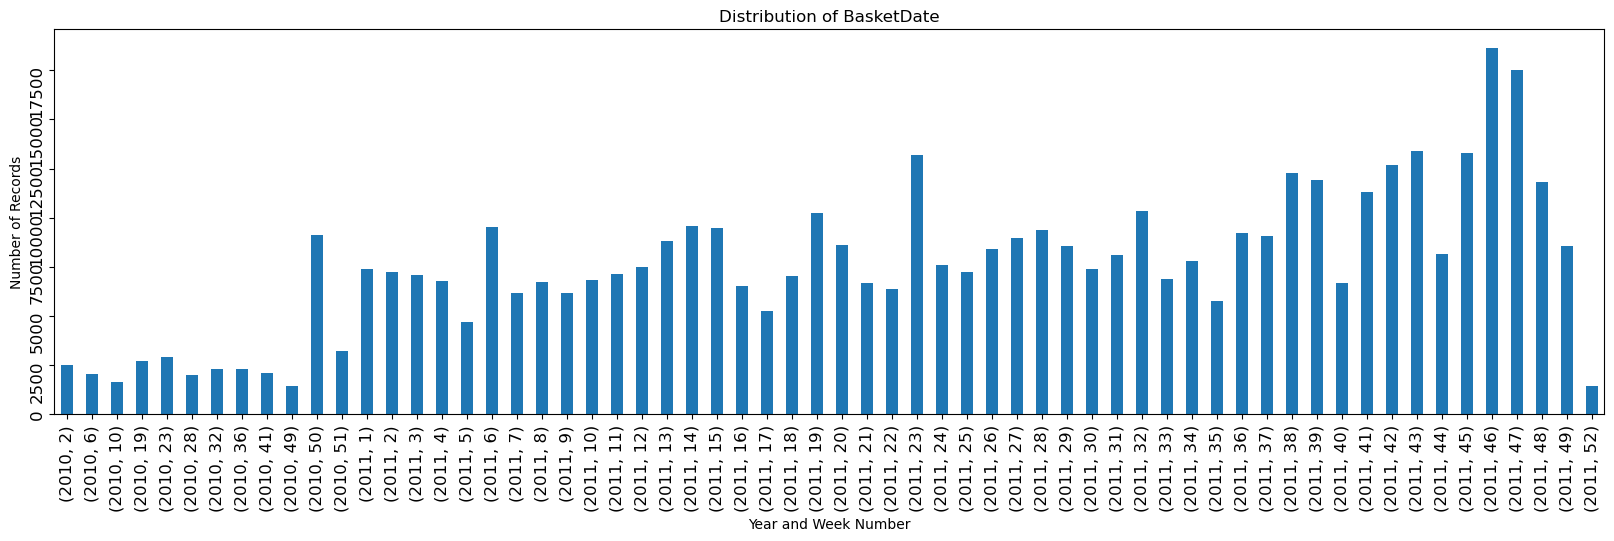

In [1014]:
# Distribution of BasketDate by week using the updated method
plt.figure(figsize=(20, 5))
df['BasketDate'].groupby(
    [df['BasketDate'].dt.year, df['BasketDate'].dt.isocalendar().week]
).agg('count').plot(kind="bar")
plt.title("Distribution of BasketDate")
plt.xlabel("Year and Week Number")
plt.ylabel("Number of Records")
plt.tick_params(labelrotation=90, labelsize='large')
plt.show()

### Deeper Insights into BasketDate

#### Distribution by Year
We analyze the distribution of records across years to understand transaction trends over time.


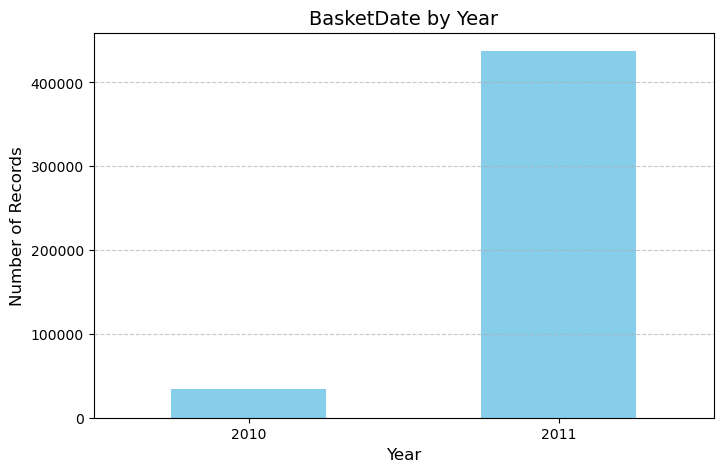

In [1015]:
# Distribution of BasketDate by year
plt.figure(figsize=(8, 5))  
df['BasketDate'].dt.year.value_counts().sort_index().plot(kind="bar", color='skyblue')
plt.title("BasketDate by Year", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Records", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Distribution by Month
We further analyze the monthly distribution of records to observe seasonal trends, such as increased transactions during specific times of the year.

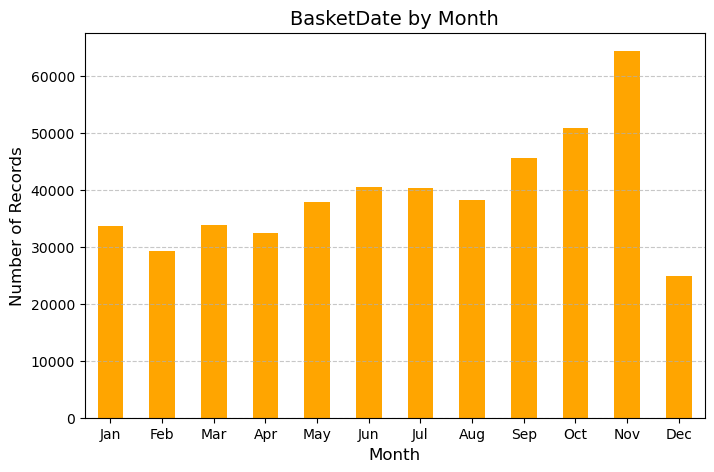

In [1016]:
# Distribution of BasketDate by month
plt.figure(figsize=(8, 5))  # Set figure size for better readability
df['BasketDate'].dt.month.value_counts().sort_index().plot(kind="bar", color='orange')
plt.title("BasketDate by Month", fontsize=14)
plt.xlabel("Month", fontsize=12)  # Simpler label
plt.ylabel("Number of Records", fontsize=12)
plt.xticks(ticks=range(0, 12), labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### **By Month**:
1. A **sharp increase** in records is observed in November, indicating higher activity leading up to December.
2. **December's lower activity** may suggest fewer transactions during or after the holiday peak.

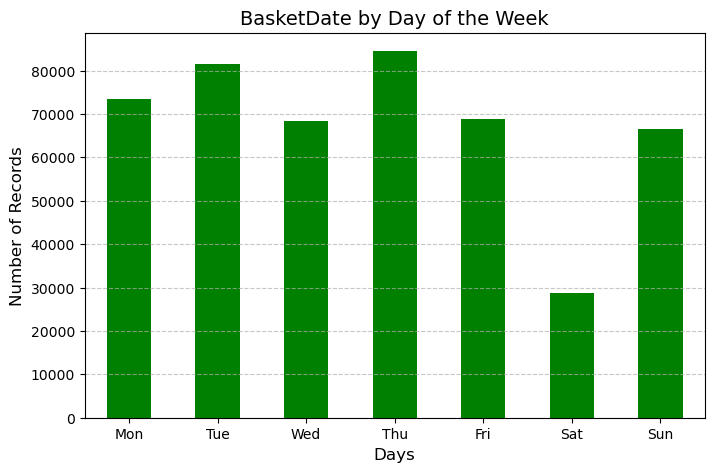

In [1017]:
# Distribution of BasketDate by days of the week
plt.figure(figsize=(8, 5))
df['BasketDate'].dt.weekday.value_counts().sort_index().plot(kind="bar", color='green')
plt.title("BasketDate by Day of the Week", fontsize=14)
plt.xlabel("Days", fontsize=12)
plt.ylabel("Number of Records", fontsize=12)
plt.xticks(ticks=range(7), labels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


#### Observation By Day of the Week:
1. Activity is **consistent across weekdays**, with a slight dip on Saturdays.
2. **Sundays** show a **surprisingly high number of transactions**, contrary to the assumption of lower weekend activity.

### BasketDate Analysis by Hours of the Day
- we need to  analyze the hourly distribution of records to infer business hours and identify peak activity times.

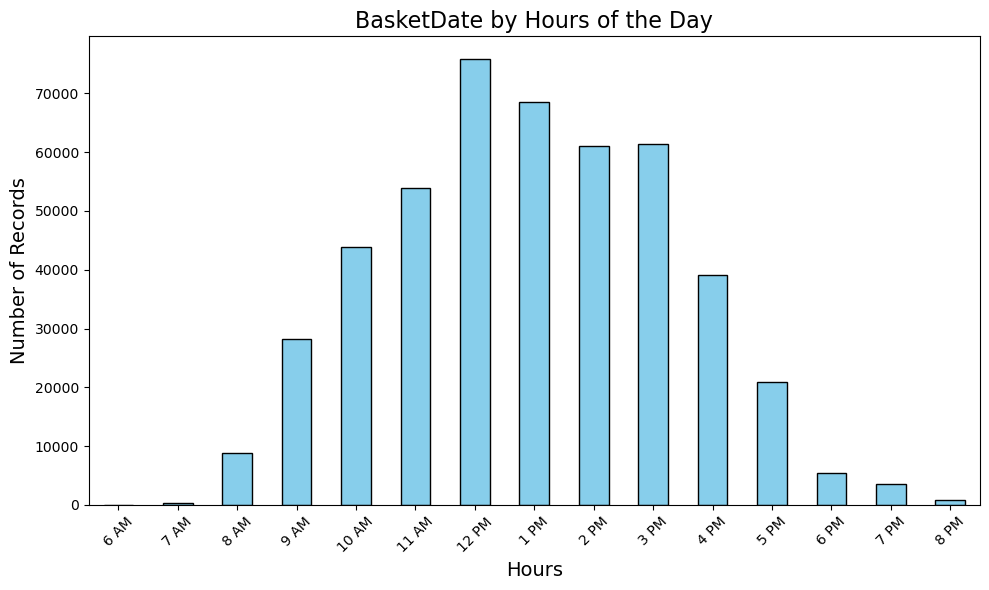

In [1018]:
# Group by the hour (24-hour format) and count the records
count_by_hour = df.groupby(df['BasketDate'].dt.hour)['BasketDate'].count()

# Function to convert 24-hour to 12-hour format with AM/PM
def convert_to_12hr(hour):
    if hour == 0:
        return '12 AM'
    elif 1 <= hour < 12:
        return f'{hour} AM'
    elif hour == 12:
        return '12 PM'
    else:
        return f'{hour - 12} PM'

# Apply the conversion to create labels
labels_12hr = [convert_to_12hr(hour) for hour in count_by_hour.index]

# Plot the bar chart
plt.figure(figsize=(10, 6))
count_by_hour.plot(kind='bar', color='skyblue', edgecolor='black')

# Set the x-ticks to the 12-hour format labels
plt.xticks(ticks=range(len(labels_12hr)), labels=labels_12hr, rotation=45)

# Set titles and labels
plt.title("BasketDate by Hours of the Day", fontsize=16)
plt.xlabel("Hours", fontsize=14)
plt.ylabel("Number of Records", fontsize=14)

# Optional: Improve layout
plt.tight_layout()

# Show the plot
plt.show()

### Observations
- **Peak Hours**: Most transactions occur between **12 PM and 3 PM**, with the highest activity at **12 PM**.
- **Moderate Activity**: Transactions gradually decrease after **3 PM**, staying relatively high until **4 PM**.
- **Minimal Activity**: There’s very little activity before **8 AM** and after **6 PM**, indicating these may be non-operational hours.

### Sale Attribute:

#### **Skewness**
The skewness of the `Sale` attribute is measured to determine the asymmetry of the distribution.

In [1019]:
# Calculate skewness of Sale attribute
df['Sale'].skew()

251.7701943919373

### **Observations**

1. **Skewness** (Direction and bias):
   - The skewness value is **251.77**, indicating a strong positive skew.
   - This suggests that most `Sale` values are concentrated on the lower end, with some extremely high values pulling the distribution to the right.

#### **Kurtosis**
The kurtosis of the `Sale` attribute tells us about the presence and influence of outliers in the dataset.

In [1020]:
# Calculate kurtosis of Sale attribute
df['Sale'].kurt()

107198.93129197924

2. **Kurtosis** (Outliers and extremes):
   - The kurtosis value is **107198.93**, showing a highly peaked distribution with long tails.
   - This indicates the presence of extreme outliers in the dataset.

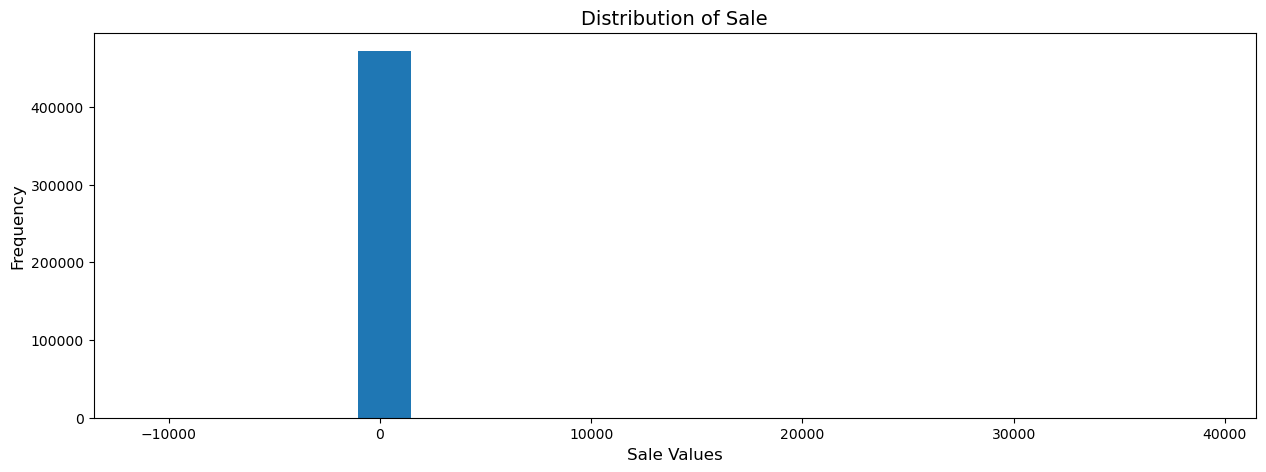

In [1021]:
# Plotting the histogram of Sale attribute
f, axs = plt.subplots(figsize=(15, 5))
axs.hist(df['Sale'], bins='sturges')  # 'sturges' for optimal bin width
axs.set_title("Distribution of Sale", fontsize=14)
axs.set_xlabel("Sale Values", fontsize=12)
axs.set_ylabel("Frequency", fontsize=12)
plt.show()

#### Observation
- The presence of outliers and the large difference in values for the Sale attribute makes it hard to clearly visualize its distribution.

### **CustomerID**

#### **Objective**:
Calculate the total number of distinct values for the `CustomerID` attribute.

In [1022]:
# Count distinct CustomerIDs
len(df['CustomerID'].unique())

4373

### **CustomerCountry**

#### **Objective**:
Determine the number of unique countries in the `CustomerCountry` attribute.

In [1023]:
# Count unique CustomerCountry values
df['CustomerCountry'].value_counts().count()

38

#### **Step 2**: Distribution of Records by Country
#### **Objective**:
Display the number of records for each country in the dataset.

In [1024]:
# Distribution of records among CustomerCountry values
df['CustomerCountry'].value_counts()

United Kingdom          426261
Germany                   9495
France                    8525
EIRE                      7824
Spain                     2533
Netherlands               2371
Belgium                   2069
Switzerland               1932
Portugal                  1495
Australia                 1259
Norway                    1086
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Unspecified                340
USA                        291
Israel                     269
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Hong Kong                  138
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         58
Lebanon 

#### Observation
**Country Distribution**:
   - The **United Kingdom** dominates the dataset with most records, likely indicating it as the primary market.
   - Other countries, like **Germany**, have significantly fewer records.

In [1025]:
# Calculate the percentage of records for each CustomerCountry
country_distribution = df['CustomerCountry'].value_counts(normalize=True) * 100

# Combine absolute counts and percentages for display
country_stats = df['CustomerCountry'].value_counts().to_frame(name='Count')
country_stats['Percentage'] = country_distribution

# Display the result
country_stats

,Count,Percentage
United Kingdom,426261,90.33
Germany,9495,2.01
France,8525,1.81
EIRE,7824,1.66
Spain,2533,0.54
Netherlands,2371,0.50
Belgium,2069,0.44
Switzerland,1932,0.41
Portugal,1495,0.32
Australia,1259,0.27


### **Observation**

1. **Dominance of the United Kingdom**:
   - The majority of the records (**90.33%**) belong to the **United Kingdom**, indicating it as the primary market.

2. **Unspecified Records**:
   - **Unspecified** country contributes **0.07%**, which may require further investigation or imputation .

### Distribution Including and Excluding the UK

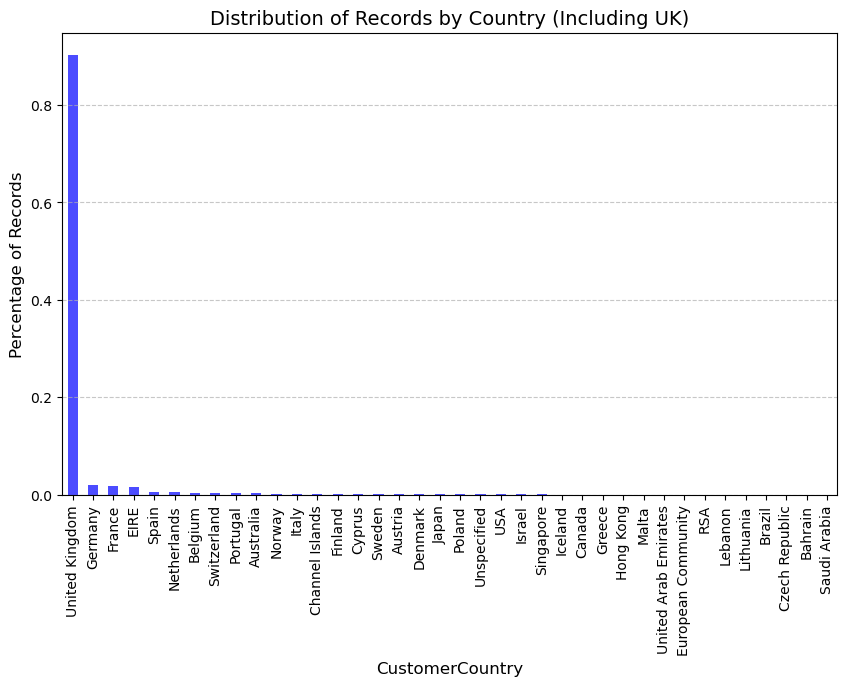

In [1026]:
# distribution with UK
plt.figure(figsize=(10, 6))
df['CustomerCountry'].value_counts(normalize=True).plot(kind='bar', color='blue', alpha=0.7)
plt.title("Distribution of Records by Country (Including UK)", fontsize=14)
plt.xlabel("CustomerCountry", fontsize=12)
plt.ylabel("Percentage of Records", fontsize=12)
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Distribution without UK

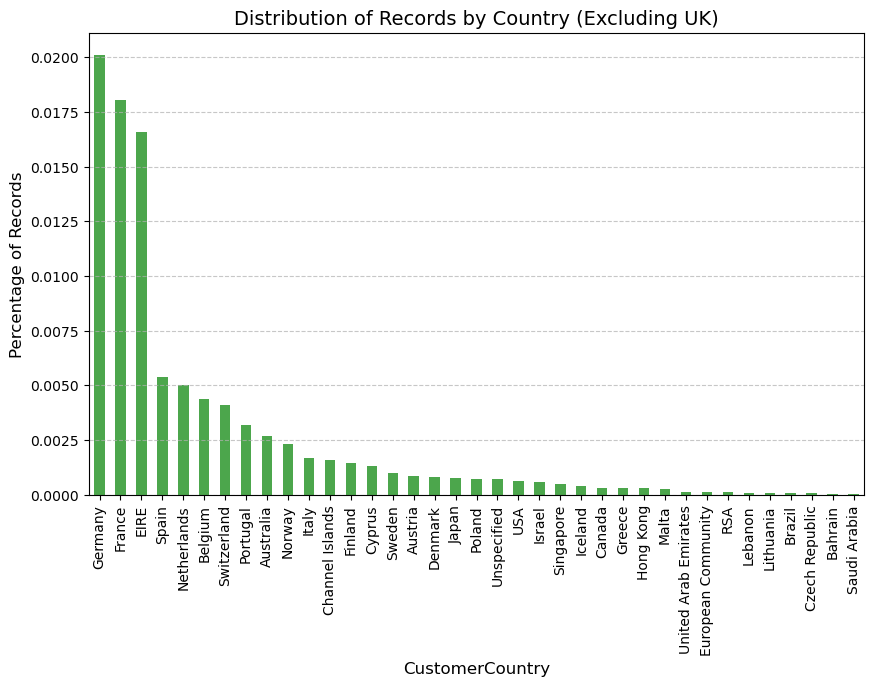

In [1027]:
countries_excluding_uk = df['CustomerCountry'].value_counts(normalize=True).drop('United Kingdom')

plt.figure(figsize=(10, 6))
countries_excluding_uk.plot(kind='bar', color='green', alpha=0.7)
plt.title("Distribution of Records by Country (Excluding UK)", fontsize=14)
plt.xlabel("CustomerCountry", fontsize=12)
plt.ylabel("Percentage of Records", fontsize=12)
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### **ProdID**
Objective: Calculate the total number of distinct product IDs in the dataset.

In [1028]:
len(df['ProdID'].unique())

3953

#### **ProdDescr**
Objective: Calculate the total number of distinct product descriptions in the dataset.


In [1029]:
len(df['ProdDescr'].unique())

4098

#### **Qta (Quantity)**
##### **1. Skewness**
- Objective: Compute the skewness of the `Qta` (quantity) attribute.

In [1030]:
df['Qta'].skew()

0.20476694612755456

##### **2. Kurtosis**
Objective: Compute the kurtosis of the `Qta` attribute.

In [1031]:
df['Qta'].kurt()

108564.3822352365

- indicating an extremely high peak.

##### **3. Histogram** 
Objective: Plot the distribution of the `Qta` attribute to visualize its skewness and kurtosis.

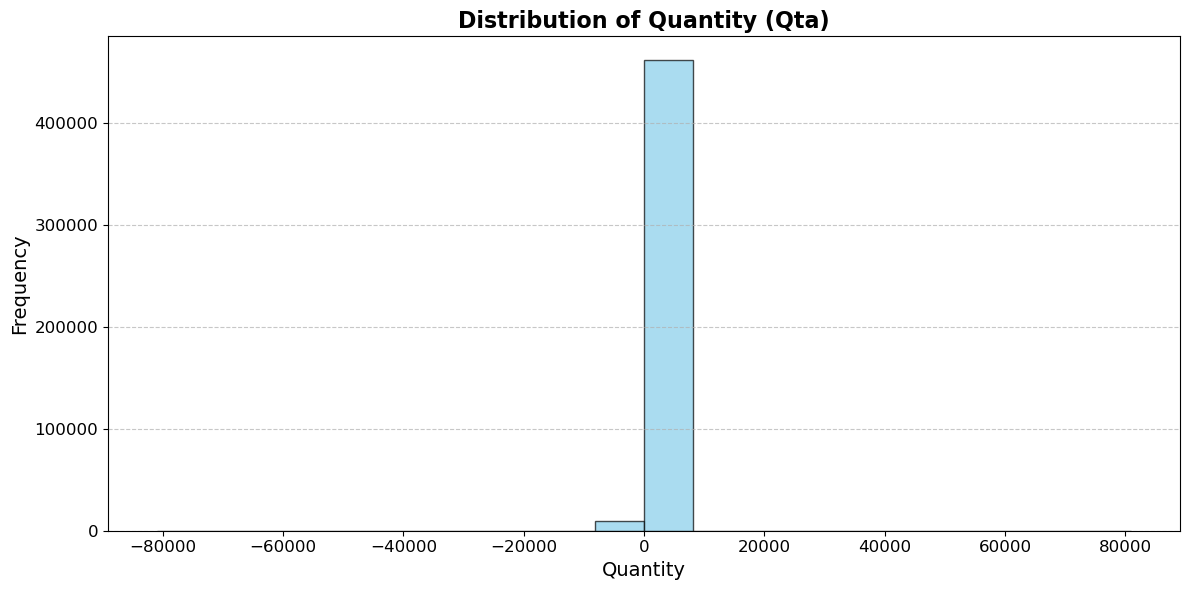

In [1032]:
import matplotlib.pyplot as plt

#  Qta Distribution Plot
plt.figure(figsize=(12, 6))  # for better readability
plt.hist(df['Qta'], bins='sturges', color='skyblue', edgecolor='black', alpha=0.7)
plt.title("Distribution of Quantity (Qta)", fontsize=16, fontweight='bold')
plt.xlabel("Quantity", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)  # gridlines to y-axis for better clarity
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()  # Ensure no elements are cut off
plt.show()

### **Observations**
1. **ProdID and ProdDescr**:
   - There are **3953 unique product IDs** but **4098 unique product descriptions**, indicating that some products may share similar descriptions.

2. **Qta (Quantity)**:
   - The skewness of `0.2047` suggests a nearly symmetric distribution.
   - The kurtosis of `108564.38` indicates an extremely sharp peak, possibly due to a high concentration of values around a central point.

3. **Visual Confirmation**:
   - The histogram of `Qta` supports the high kurtosis observation with a sharp peak and slight asymmetry.

## Data Preprocessing

### 1. Handling Duplicates

In [1033]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()

# Total rows
total_rows = len(df)

# Print summary
print(f"Total rows: {total_rows}")
print(f"Duplicate rows: {duplicate_count}")
print(f"Percentage of duplicates: {duplicate_count / total_rows * 100:.2f}%")

Total rows: 471910
Duplicate rows: 5232
Percentage of duplicates: 1.11%


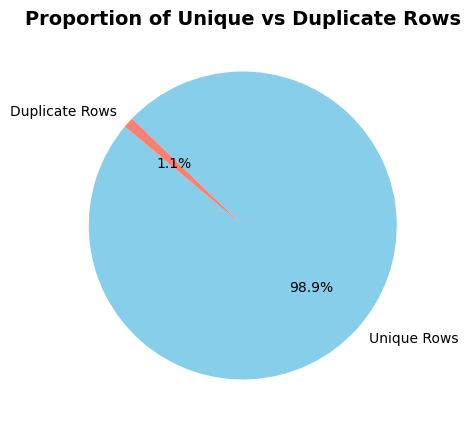

In [1034]:
# Data for visualization
labels = ['Unique Rows', 'Duplicate Rows']
sizes = [total_rows - duplicate_count, duplicate_count]
colors = ['skyblue', 'salmon']

# Plot
plt.figure(figsize=(8, 5))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title("Proportion of Unique vs Duplicate Rows", fontsize=14, fontweight='bold')
plt.show()

In [1035]:
# Extract duplicate rows
duplicates = df[df.duplicated()]

# Display duplicate rows for investigation
duplicates.head()

,BasketID,BasketDate,Sale,CustomerID,CustomerCountry,ProdID,ProdDescr,Qta
517,536409,2010-01-12 11:45:00,1.25,17908.00,United Kingdom,21866,UNION JACK FLAG LUGGAGE TAG,1
527,536409,2010-01-12 11:45:00,2.10,17908.00,United Kingdom,22866,HAND WARMER SCOTTY DOG DESIGN,1
537,536409,2010-01-12 11:45:00,2.95,17908.00,United Kingdom,22900,SET 2 TEA TOWELS I LOVE LONDON,1
539,536409,2010-01-12 11:45:00,4.95,17908.00,United Kingdom,22111,SCOTTIE DOG HOT WATER BOTTLE,1
555,536412,2010-01-12 11:49:00,2.95,17920.00,United Kingdom,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1


In [1036]:
# Filter specific duplicate records based on product description and customer ID
df[(df['ProdDescr'] == "UNION JACK FLAG LUGGAGE TAG") &  (df['CustomerID'] == 17908)]

,BasketID,BasketDate,Sale,CustomerID,CustomerCountry,ProdID,ProdDescr,Qta
494,536409,2010-01-12 11:45:00,1.25,17908.00,United Kingdom,21866,UNION JACK FLAG LUGGAGE TAG,1
517,536409,2010-01-12 11:45:00,1.25,17908.00,United Kingdom,21866,UNION JACK FLAG LUGGAGE TAG,1


#### **Reason for Duplication**
- Likely due to data entry errors or system glitches rather than intentional duplication.
#### **Action**:
- Removing duplicates ensures cleaner data and avoids interference in further analysis.
- Dataset integrity is improved, reducing redundancy.



In [1037]:
# Remove duplicates in the entire dataset
df.drop_duplicates(inplace=True)

# Verify if duplicates are removed
print(df.duplicated().any()) 

False


### 2. Handling Missing Values

In [1038]:
# Check for missing values in the dataset
missing_values = df.isnull().any()
missing_values

BasketID           False
BasketDate         False
Sale               False
CustomerID          True
CustomerCountry    False
ProdID             False
ProdDescr           True
Qta                False
dtype: bool

### 2.1 Handling Missing Values in Numerical Attributes

#### **Check for Zero Values in Numerical Attributes**
1. **Qta (Quantity)**:

In [1039]:
zero_qta_count = df[df.Qta == 0].Qta.count()
print(f"Number of zero values in Qta: {zero_qta_count}")

Number of zero values in Qta: 0


2. **Sale**:

In [1040]:
zero_sale_count = df[df.Sale == 0].Sale.count()
print(f"Number of zero values in Sale: {zero_sale_count}")

Number of zero values in Sale: 1278




#### **Observation**
1. **Missing Values**:
   - Missing values exist in `CustomerID` and `ProdDescr`.
   - These require imputation or exclusion depending on the context.

2. **Zero Values**:
   - **`Qta`**: No zero values, so no further action needed.
   - **`Sale`**: Contains 1,278 zero values. However, given the transactional nature of the dataset, these zeros may have significance (e.g., returns or adjustments) and will not be treated as missing.

3. **Action Plan**:
   - Address missing values in categorical attributes (`CustomerID` and `ProdDescr`).
   - Retain zero values in `Sale` for analysis, as they could provide useful insights.

### 2.2 Handling Missing Values in Categorical Columns

#### 1. Missing values in CustomerCountry
- We compute a list of all the different values associated with the CustomerCountry attribute.

In [1041]:
df.CustomerCountry.value_counts()

United Kingdom          421106
Germany                   9480
France                    8509
EIRE                      7814
Spain                     2528
Netherlands               2371
Belgium                   2069
Switzerland               1931
Portugal                  1486
Australia                 1258
Norway                    1086
Italy                      803
Channel Islands            757
Finland                    695
Cyprus                     611
Sweden                     461
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Unspecified                337
USA                        291
Israel                     266
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Hong Kong                  137
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         58
Lebanon 

#### 1.1 Handling Missing and "Unspecified" Values in `CustomerCountry`

####  Identify "Unspecified" Records**
- **Objective**: Handle rows where `CustomerCountry` has the value `"Unspecified"`.

In [1042]:
unspecified_ids = df[df.CustomerCountry == 'Unspecified'].CustomerID.value_counts()
print(unspecified_ids.keys())

Float64Index([12743.0, 16320.0, 14265.0, 12363.0], dtype='float64')


#### **1.2: Check for Consistency**
   1. We identified a group of customers whose `CustomerCountry` is `"Unspecified"`. These customers have specific `CustomerID` values like `12743.0`, `16320.0`, etc.

   2. We look at all the records for these customers and ask:
   - Do these customers always have `"Unspecified"` in the `CustomerCountry` column?
   - Or are they sometimes associated with other valid country names like `"United Kingdom"`, `"France"`, etc.?

- Why is this important?
    - If the `CustomerCountry` was inconsistent for these customers (e.g., `"Unspecified"` in some rows and `"United Kingdom"` in others), it would mean `"Unspecified"` might not be reliable.
    - Since it is consistent, we can confidently treat these customers as a separate group or decide how to handle `"Unspecified"` (e.g., replacing it or leaving it as is).

In [1043]:
df.loc[df.CustomerID.isin(unspecified_ids.keys())].CustomerCountry.value_counts()

Unspecified    241
Name: CustomerCountry, dtype: int64

#### **1.3 : Investigate Remaining Records**
- Check for any records where `CustomerCountry` is `"Unspecified"` but `CustomerID` is missing.

In [1044]:
df[df.CustomerCountry == "Unspecified"].isna().CustomerID.value_counts()

False    241
True      96
Name: CustomerID, dtype: int64

#### **Observation**
1. **Consistency**:
   - All `CustomerID` values tied to `"Unspecified"` records are consistent.
   - These can be treated as a separate group.

2. **Autonomous Records**:
   - 96 records with `"Unspecified"` and missing `CustomerID` are independent.

3. **Replacement**:
   - It’s possible to replace `"Unspecified"` with the most frequent value (`United Kingdom`), but 1clustering analysis` might offer better results.

#### **2. Identify Missing `CustomerID` Values**:
   - First, we check how many missing values (`NaN`) are present in the `CustomerID` column.

In [1045]:
df.CustomerID.isnull().sum()

65073

#### 2.1 **Replacement Strategy**:
- To fill these missing `CustomerID` values, we use the most common `CustomerID` (mode) for each `CustomerCountry`.
- For example, if `Australia` has the most frequent `CustomerID` as `12415.00`, then we assign `12415.00` to all missing `CustomerID` rows where `CustomerCountry` is `Australia`.

#### **Calculation of Mode**:
- We group the data by `CustomerCountry` and calculate the mode of the `CustomerID` for each country.
- The result shows the most common `CustomerID` for each `CustomerCountry`.

#### Why This Approach?
- The mode provides a reasonable guess for the missing `CustomerID` based on the typical customer behavior in that country.
- This method ensures consistency and minimizes random or arbitrary assignments.


#### Compute the Most Frequent CustomerID for Each CustomerCountry

In [1046]:
# Calculate the mode of CustomerID for each CustomerCountry
country_mode = df.groupby(['CustomerCountry']).agg(lambda x:x.mode()).CustomerID
country_mode

CustomerCountry
Australia              12415.00
Austria                12360.00
Bahrain                12355.00
Belgium                12362.00
Brazil                 12769.00
Canada                 17444.00
Channel Islands        14936.00
Cyprus                 12359.00
Czech Republic         12781.00
Denmark                12406.00
EIRE                   14911.00
European Community     15108.00
Finland                12428.00
France                 12681.00
Germany                12471.00
Greece                 12717.00
Hong Kong                    []
Iceland                12347.00
Israel                 12688.00
Italy                  12584.00
Japan                  12753.00
Lebanon                12764.00
Lithuania              15332.00
Malta                  17828.00
Netherlands            14646.00
Norway                 12433.00
Poland                 12779.00
Portugal               12757.00
RSA                    12446.00
Saudi Arabia           12565.00
Singapore              1

**Observation**:  

The mode of `CustomerID` was calculated for each `CustomerCountry`, showing the most frequent `CustomerID` per country. For "Hong Kong," no `CustomerID` was found, so a custom ID will be added to ensure all records have a valid value.

In [1047]:
# We will check to see if the custom ID is already present within the dataset 
df[df.CustomerID == "18288.0"].CustomerID.count() 

0

In [1048]:
country_mode["Hong Kong"] = "18288.0"

In [1049]:
# Replace missing values in CustomerID using the mode for each CustomerCountry
df['CustomerID'] = df['CustomerID'].fillna(df['CustomerCountry'].map(country_mode))

In [1050]:
# Verify that all missing values have been replaced
df.CustomerID.isnull().sum()

0

**Handling Records Related to Canceled Purchases**

We aim to analyze the dataset to identify records with negative values in the `Qta` attribute, which may represent canceled purchases. Specifically, we:
1. Count the total number of records in the dataset.
2. Identify the records where `Qta` is negative.
3. Further filter the records to include only those with negative `Qta` values and `BasketID` containing the letter `'C'`.

In [1051]:
# Count total records in the dataset
print('Records within the dataset: ' + str(df.BasketID.count()))

# Count records with negative values for Qta
print('Records within the dataset with negative values of Qta: ' + str(df[df.Qta < 0].BasketID.count()))

# Count records with negative Qta and BasketID containing 'C'
print('Records within the dataset with negative values of Qta and BasketId containing \'C\': ' + str(df[(df.Qta < 0) & (df.BasketID.str.contains('C'))].BasketID.count()))

Records within the dataset: 466678
Records within the dataset with negative values of Qta: 9719
Records within the dataset with negative values of Qta and BasketId containing 'C': 9051


### Observation
1. The **total records** in the dataset give a baseline for comparison.
2. A subset of records with **negative `Qta` values** identifies potential canceled purchases.
3. Among these, the records where `BasketID` contains `'C'` represent a significant subset, suggesting a specific category or pattern of canceled transactions. 
- We address records with negative `Qta` values (canceled purchases) by matching them with corresponding positive `Qta` values for the same product and customer. The steps include:  

1. **Match Records**: Find matching positive and negative `Qta` records by `CustomerID` and `ProdID`.  
2. **Adjust or Remove**:  
   - If `Qta` values are equal, remove both records.  
   - If positive `Qta` is larger, subtract the negative value and update the positive record, then remove the negative record.  
   - If negative `Qta` is larger, adjust the negative record and remove the positive record.  

In [1052]:
from collections import defaultdict

def balance_dataset(df):
    """
      For each negative row:
         - Find positives for the same (CustomerID, ProdID)
         - If they match exactly, remove both
         - If pos > abs(neg), reduce pos
         - If abs(neg) > pos, reduce neg

    """
    
    pos_dict = defaultdict(list)

    # We'll accumulate the "surviving" or "residual" rows here.
    final_rows = []

    # To ensure we process in the correct order, iterate over df in ascending index
    # (or by sorted date if that’s how your original loop runs).
    # NOTE: If your df is already in the desired order, you could just do `for row in df.itertuples():`
    for idx, row in df.sort_index().iterrows():
        qta = row['Qta']
        cid = row['CustomerID']
        pid = row['ProdID']

        if qta > 0:
            # Enqueue this positive row
            # We store a *copy* of the row so we can update Qta if needed
            pos_dict[(cid, pid)].append([idx, qta, row.to_dict()])
            
        elif qta < 0:
            needed = abs(qta)

            # Keep matching against the earliest positive rows
            while needed > 0 and pos_dict[(cid, pid)]:
                pos_idx, pos_qta, pos_data = pos_dict[(cid, pid)][0]

                if pos_qta == needed:
                    # Perfect match: drop both
                    pos_dict[(cid, pid)].pop(0)  # remove the used-up positive
                    needed = 0
                elif pos_qta > needed:
                    # Positive is bigger: reduce it
                    pos_dict[(cid, pid)][0][1] = pos_qta - needed
                    pos_dict[(cid, pid)][0][2]['Qta'] = pos_qta - needed
                    needed = 0
                else:
                    # pos_qta < needed
                    # Use up this positive
                    pos_dict[(cid, pid)].pop(0)
                    needed -= pos_qta

            # If we still have leftover negative Qta, keep it in final output
            if needed > 0:
                row_data = row.to_dict()
                row_data['Qta'] = -needed
                final_rows.append((idx, row_data))

        else:
            # qta == 0 -> Just keep it as-is (if your logic says so)
            final_rows.append((idx, row.to_dict()))

    # Now, any positives left in pos_dict are unmatched or partially used
    # We keep them in the final dataset
    for key, entries in pos_dict.items():
        for pos_idx, pos_qta, pos_data in entries:
            final_rows.append((pos_idx, pos_data))

    # Build a DataFrame from final_rows
    out = pd.DataFrame(
        data=[d for (_, d) in final_rows],
        index=[i for (i, _) in final_rows]
    )
    # Sort by index to restore the final order
    out.sort_index(inplace=True)
    return out


In [1053]:
df = balance_dataset(df)
print("Balanced size:", len(df))

Balanced size: 451982


### Observation  
1. **Removed Records**: Equal positive and negative `Qta` records were removed.  
2. **Adjusted Records**: Remaining records were updated with the net `Qta`.  
3. **Improved Data Quality**: Canceled purchases no longer distort the dataset. This ensures better accuracy for further analysis.

In [1054]:
print('Records within the dataset: ' + str(df.BasketID.count()))
print('Records within the dataset with negative values of Qta: ' + str(df[df.Qta < 0].BasketID.count()))
print('Records within the dataset with negative values of Qta and BasketId containing \'C\': ' + str(df[(df.Qta < 0) & (df.BasketID.str.contains('C'))].BasketID.count()))

Records within the dataset: 451982
Records within the dataset with negative values of Qta: 1995
Records within the dataset with negative values of Qta and BasketId containing 'C': 1461


In [1055]:
df.describe()

,Sale,Qta
count,451982.00,451982.00
mean,3.89,11.16
std,84.25,47.66
min,-11062.06,-9360.00
25%,1.25,2.00
50%,2.08,4.00
75%,3.75,12.00
max,38970.00,12540.00


In [1056]:
import seaborn as sns

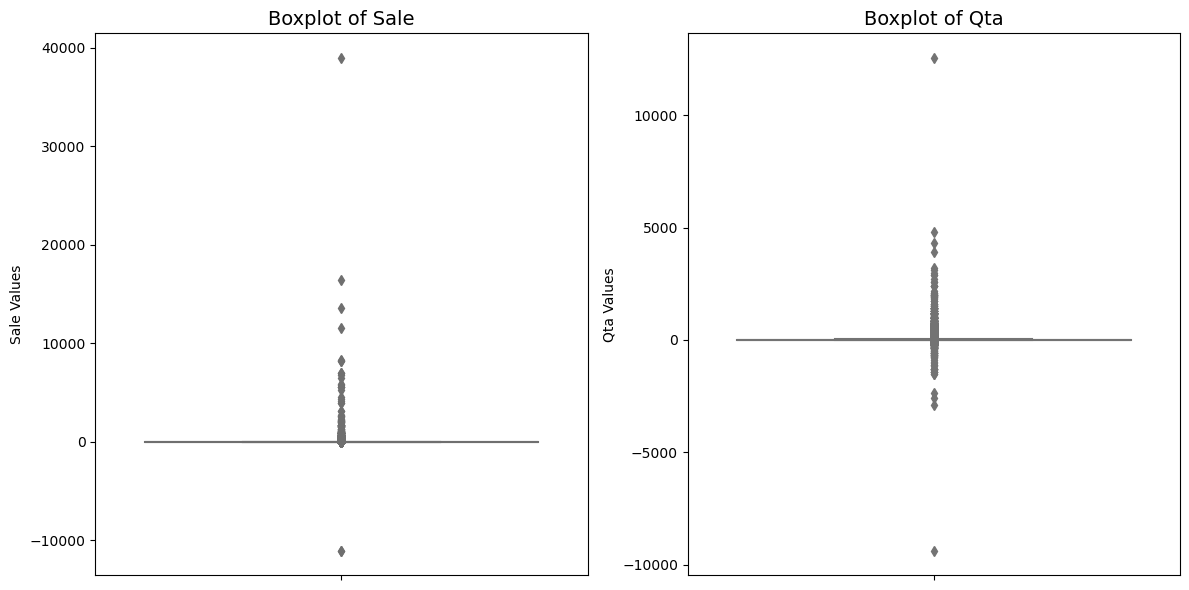

In [1057]:
# Plotting boxplots for Sale and Qta to detect outliers
fig, axs = plt.subplots(ncols=2, figsize=(12, 6))

# Boxplot for Sale
sns.boxplot(y=df['Sale'], ax=axs[0], color='skyblue')
axs[0].set_title('Boxplot of Sale', fontsize=14)
axs[0].set_ylabel('Sale Values')

# Boxplot for Qta
sns.boxplot(y=df['Qta'], ax=axs[1], color='lightgreen')
axs[1].set_title('Boxplot of Qta', fontsize=14)
axs[1].set_ylabel('Qta Values')

plt.tight_layout()
plt.show()

#### Observations
1. **Sale Values**:
   - There are significant outliers with some sales exceeding 40,000, while most data points are concentrated near the lower end of the scale.
   - Negative sale values indicate potential data errors or returns/refunds.

2. **Qta Values**:
   - The majority of quantities are close to zero, with noticeable outliers both on the positive and negative ends.
   - Extreme negative values suggest possible data entry errors or adjustments.

In [1058]:
# Function to calculate IQR bounds
def iqr_values(s): 
    q1 = s.quantile(q=0.25)
    q3 = s.quantile(q=0.75)
    iqr = q3 - q1
    iqr_left = q1 - 1.5 * iqr
    iqr_right = q3 + 1.5 * iqr
    return iqr_left, iqr_right

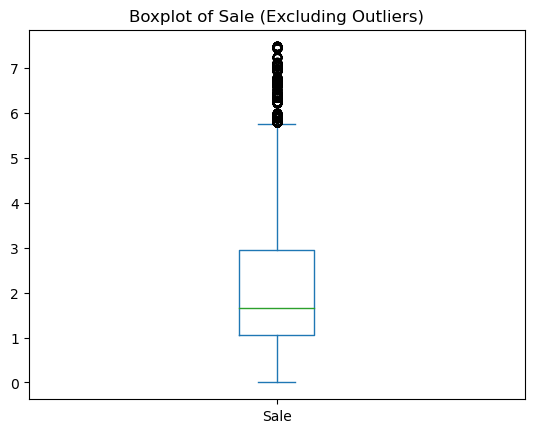

In [1059]:
# Compute IQR bounds for Sale
left_sale, right_sale = iqr_values(df.Sale)

# Plot boxplot for Sale excluding outliers
df[(df.Sale > left_sale) & (df.Sale < right_sale)].Sale.plot.box()
plt.title('Boxplot of Sale (Excluding Outliers)')
plt.show()

# Observations
- Several extreme values are still present beyond the upper whisker, indicating potential high outliers.
- The median value is below the midpoint of the IQR, suggesting a slightly skewed distribution.

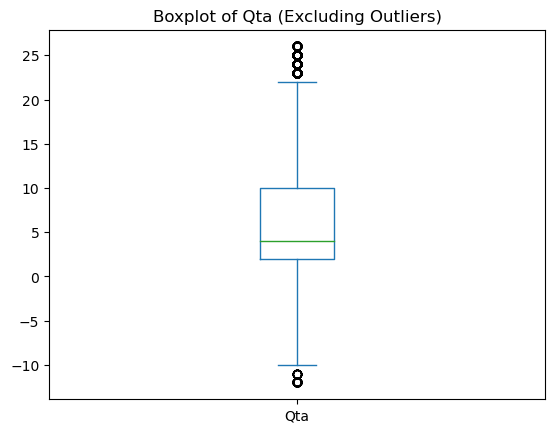

In [1060]:
# Compute IQR bounds for Qta
left_qta, right_qta = iqr_values(df.Qta)

# Plot boxplot for Qta excluding outliers
df[(df.Qta > left_qta) & (df.Qta < right_qta)].Qta.plot.box()
plt.title('Boxplot of Qta (Excluding Outliers)')
plt.show()


#### Observation:
1. The majority of data points lie within the interquartile range (IQR).
2. Outliers are present both above the upper whisker and below the lower whisker, indicating extreme values in both directions.
3. The median value is close to the center of the IQR, suggesting a relatively symmetric distribution.


#### Removing Outliers
We filter the data to exclude outliers based on the IQR bounds.

In [1061]:
# Identify records containing outliers for Sale and Qta
df_outliers = df[
    (df.Sale < left_sale) | (df.Sale > right_sale) | 
    (df.Qta < left_qta) | (df.Qta > right_qta)
]
df_outliers

,BasketID,BasketDate,Sale,CustomerID,CustomerCountry,ProdID,ProdDescr,Qta
5,536365,2010-01-12 08:26:00,7.65,17850.00,United Kingdom,22752,SET 7 BABUSHKA NESTING BOXES,2
13,536367,2010-01-12 08:34:00,1.69,13047.00,United Kingdom,84879,ASSORTED COLOUR BIRD ORNAMENT,32
20,536367,2010-01-12 08:34:00,9.95,13047.00,United Kingdom,22622,BOX OF VINTAGE ALPHABET BLOCKS,2
23,536367,2010-01-12 08:34:00,7.95,13047.00,United Kingdom,21777,RECIPE BOX WITH METAL HEART,4
24,536367,2010-01-12 08:34:00,7.95,13047.00,United Kingdom,48187,DOORMAT NEW ENGLAND,4
...,...,...,...,...,...,...,...,...
541866,581583,2011-09-12 12:23:00,1.85,13777.00,United Kingdom,85038,6 CHOCOLATE LOVE HEART T-LIGHTS,36
541867,581584,2011-09-12 12:25:00,0.72,13777.00,United Kingdom,20832,RED FLOCK LOVE HEART PHOTO FRAME,72
541868,581584,2011-09-12 12:25:00,1.85,13777.00,United Kingdom,85038,6 CHOCOLATE LOVE HEART T-LIGHTS,48
541892,581586,2011-09-12 12:49:00,8.95,13113.00,United Kingdom,21217,RED RETROSPOT ROUND CAKE TINS,24


In [1062]:
# Remove outliers by excluding the records in df_outliers
df = df.drop(df_outliers.index)

#### Step 2: Skewness and Kurtosis Calculation
With the outliers removed, we recalculate the skewness and kurtosis for both attributes.

In [1063]:
# Skewness and Kurtosis for Sale
print('Sale:')
print('Skewness: ' + str(df.Sale.skew()))
print('Kurtosis: ' + str(df.Sale.kurt()))

# Skewness and Kurtosis for Qta
print('\nQta:')
print('Skewness: ' + str(df.Qta.skew()))
print('Kurtosis: ' + str(df.Qta.kurt()))

Sale:
Skewness: 1.01421356005716
Kurtosis: 0.40417917659557023

Qta:
Skewness: 1.3182549768201888
Kurtosis: 1.01666789285055


**Observations:**
1. **Sale:**
   - Skewness: 1.01 → Indicates positive skewness, but less intense than before.
   - Kurtosis: 0.40 → Suggests wider population compared to earlier.
   
2. **Qta:**
   - Skewness: 1.31 → Still positively skewed, but less extreme.
   - Kurtosis: 1.01 → Indicates a taller distribution, but less pronounced than before.

#### Visualizing Updated Distributions
We plot the histograms to observe the changes in the distributions after removing the outliers.

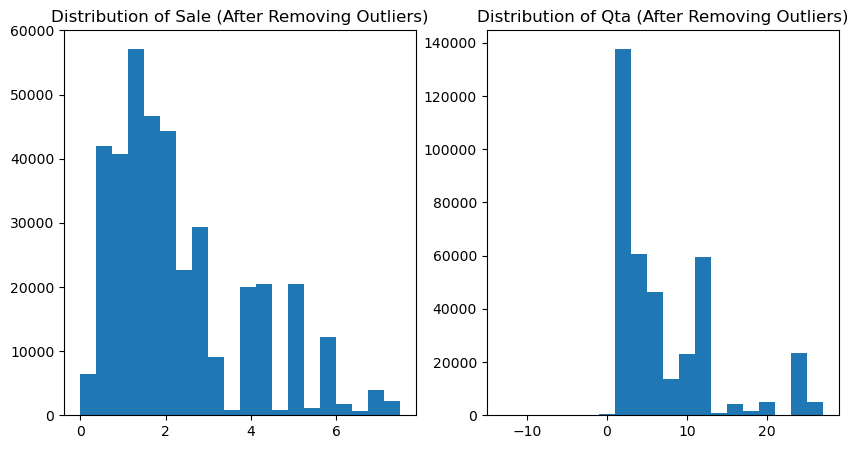

In [1064]:
# Histograms for Sale and Qta after removing outliers
f, axs = plt.subplots(ncols=2, figsize=(10, 5))

# Sale
axs[0].hist(df.Sale, bins='sturges')
axs[0].set_title('Distribution of Sale (After Removing Outliers)')

# Qta
axs[1].hist(df.Qta, bins='sturges')
axs[1].set_title('Distribution of Qta (After Removing Outliers)')

plt.show()

**Observations:**
- **Sale:** The distribution appears more balanced and less skewed, with most data concentrated around the median.
- **Qta:** The distribution shows significantly reduced skewness, indicating better symmetry.

## **Correlation Analysis**

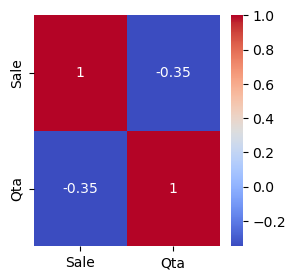

In [1065]:
# Compute correlation matrix
mat = df.corr()
# Visualize correlation matrix
fig, ax = plt.subplots(figsize=(3, 3))  # Adjust figure size as needed
sns.heatmap(mat, annot=True, cmap='coolwarm')
plt.show()


### **Observations**
- **Correlation Between Sale and Qta:**
   - The correlation coefficient is **-0.35**, indicating a weak negative relationship.
   - This suggests that as one attribute increases, the other tends to decrease slightly, but the relationship is not strong.


### **Feature Engineering**

#### **Sale as Cost Per Unit and `Sale_per_Qta`**
We compute an additional attribute, `Sale_per_Qta`, which represents the total amount spent by each customer for their transactions. This is calculated as the product of `Sale` (cost per unit) and `Qta` (quantity).

**Step 1: Compute `Sale_per_Qta`**

In [1066]:
# Calculate Sale_per_Qta as the total cost for each transaction
df['Sale_per_Qta'] = df.Sale * df.Qta

**Step 2: Plot the Distribution of `Sale_per_Qta`**

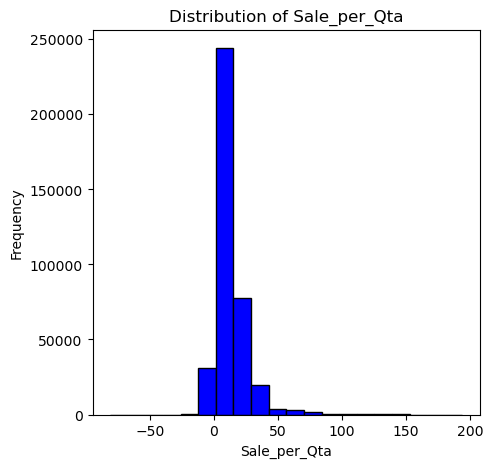

In [1067]:
# Plot the distribution of Sale_per_Qta
fig, ax = plt.subplots(figsize=(5, 5))  # Set plot size
ax.hist(df.Sale_per_Qta, bins='sturges', color='blue', edgecolor='black')
ax.set_title('Distribution of Sale_per_Qta')  # Add title
ax.set_xlabel('Sale_per_Qta')  # Add x-axis label
ax.set_ylabel('Frequency')  # Add y-axis label
plt.show()

### **Observations**
1. **Distribution Shape:**
   - The distribution is heavily skewed to the right, with most values concentrated near zero.
   -  extreme values represent significantly higher spending.

2. **Negative Values:**
   - The presence of negative values suggests possible data entry issues or returns (e.g., refunds or corrections).

### **Data Visualization**

#### **Function: `autolabel`**
The `autolabel` function is designed to enhance bar plots by annotating the height of each bar directly on the chart. This is especially useful for better readability and understanding of the data being represented.

In [1068]:
def autolabel(rects, i=None, j=None):
    """
    Attach a text label above each bar in *rects*, displaying its height.
    This function is adaptable to subplots or single plots.
    """
    for rect in rects:
        height = rect.get_height()
        if i is not None and j is not None:
            axs[i][j].annotate(
                f'{height:.0f}',  # Format height as integer
                xy=(rect.get_x() + rect.get_width() / 2, height),  # Position
                xytext=(0, 3),  # Offset text slightly above bar
                textcoords="offset points",
                ha='center', va='bottom'
            )
        elif i is not None:
            axs[i].annotate(
                f'{height:.0f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom'
            )
        else:
            plt.annotate(
                f'{height:.0f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom'
            )


### **Periodical Plots**
To analyze the behavior of attributes like **Sale** and **Qta** over time, we create a new dataframe using the `BasketDate` attribute as the index.
   - Transforming the `BasketDate` column into a datetime index enables time-series analysis.
   - Attributes like `Sale` and `Qta` can now be plotted against time to observe trends or patterns.

In [1069]:
# Duplicate the dataframe and set BasketDate as the index in datetime format
df2 = df.copy()
df2.index = pd.to_datetime(df['BasketDate'], format='%d/%m/%y %H:%M')

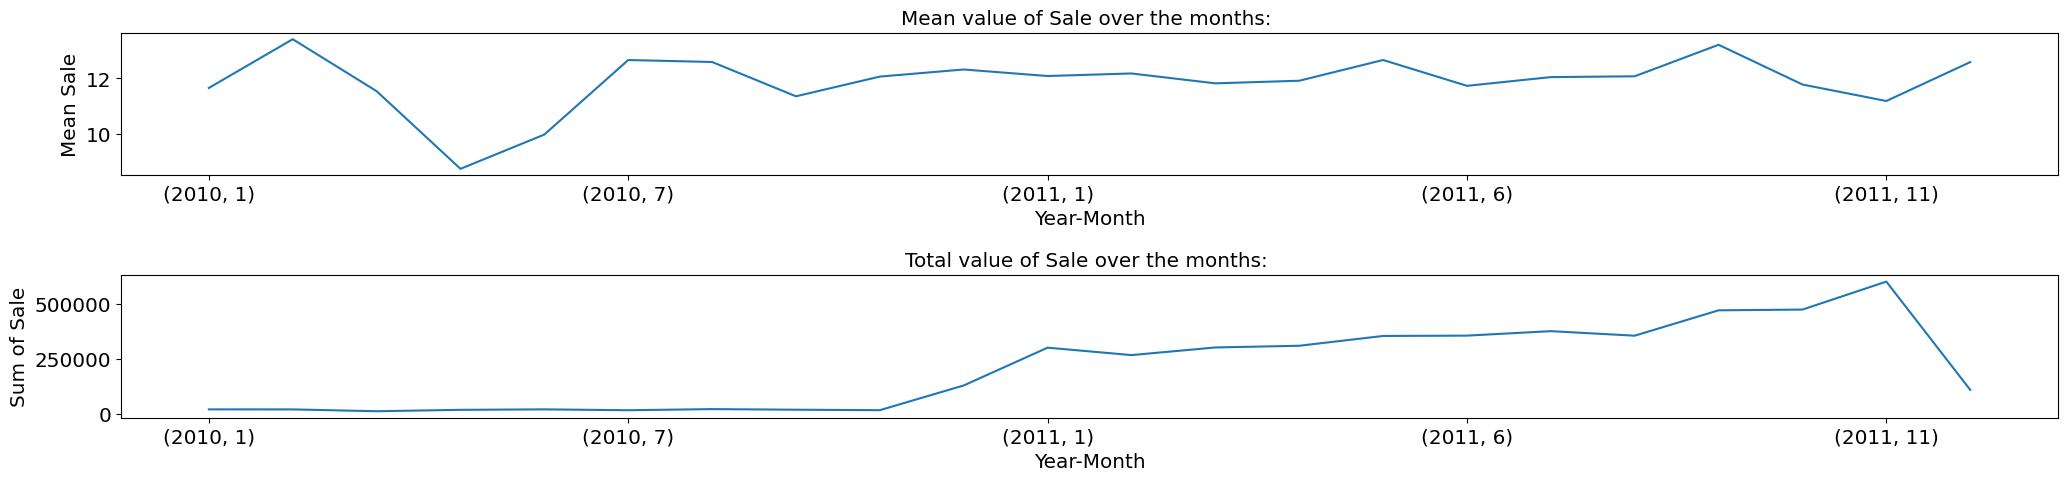

In [1070]:
# Set up a grid of plots:
fig = plt.figure(figsize=(25, 5))
fig_dims = (2, 1)
fig.subplots_adjust(hspace=0.7)

# Plot mean sales 
plt.subplot2grid(fig_dims, (0, 0))
monthly_sales_mean = df2['Sale_per_Qta'].groupby([df2.index.year, df2.index.month]).mean().plot()
plt.title('Mean value of Sale over the months: ', fontsize='x-large')
plt.xlabel('Year-Month', fontsize='x-large')
plt.ylabel('Mean Sale', fontsize='x-large')
plt.tick_params(labelsize='x-large')

# Plot total sales
plt.subplot2grid(fig_dims, (1, 0))
monthly_sales_total = df2['Sale_per_Qta'].groupby([df2.index.year, df2.index.month]).sum().plot()
plt.title('Total value of Sale over the months: ', fontsize='x-large')
plt.xlabel('Year-Month', fontsize='x-large')
plt.ylabel('Sum of Sale', fontsize='x-large')
plt.tick_params(labelsize='x-large')

plt.show()

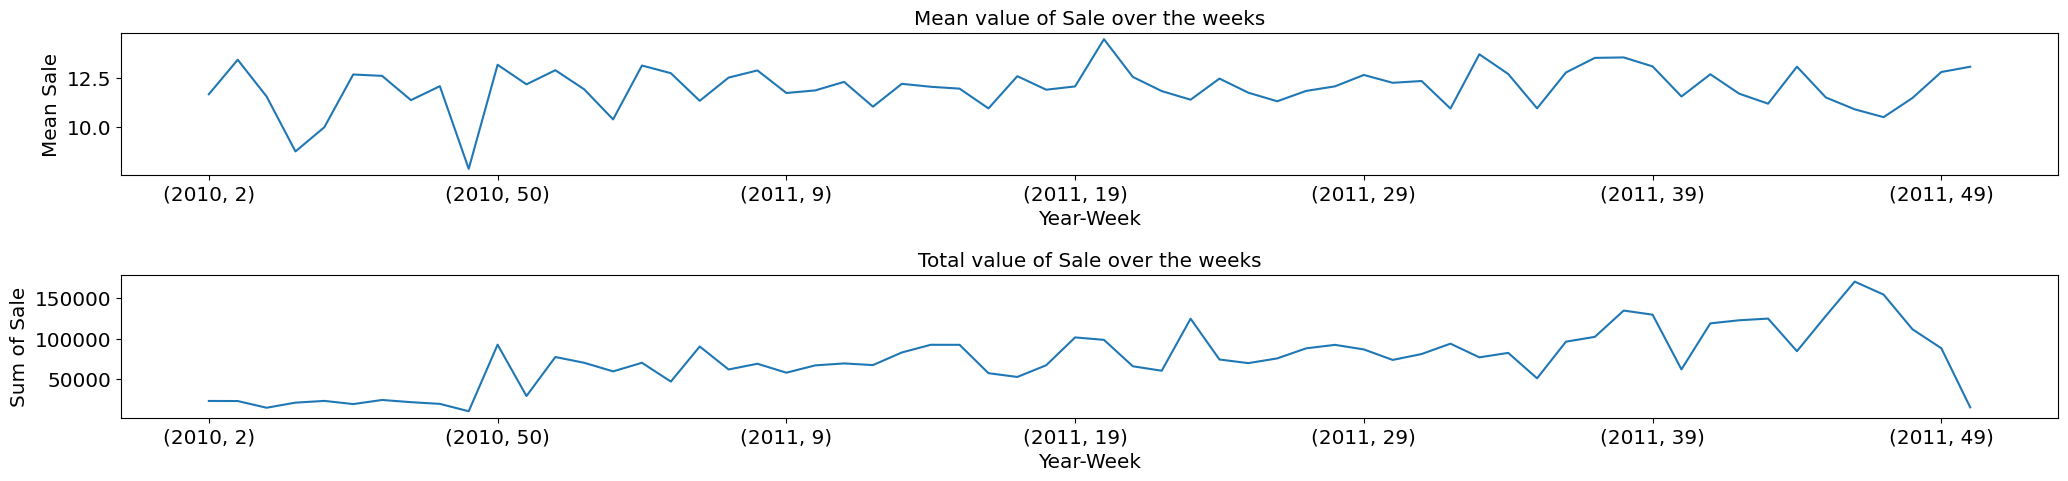

In [1071]:
# Set up a grid of plots
fig = plt.figure(figsize=(25, 5))  
fig_dims = (2, 1)
fig.subplots_adjust(hspace=0.7)

# Plot mean sales
plt.subplot2grid(fig_dims, (0, 0))
monthly_sales_mean = df2['Sale_per_Qta'].groupby([df2.index.year, df2.index.isocalendar().week]).mean().plot()
plt.title('Mean value of Sale over the weeks', fontsize='x-large')
plt.xlabel('Year-Week', fontsize='x-large')
plt.ylabel('Mean Sale', fontsize='x-large')
plt.tick_params(labelsize='x-large')

# Plot total sales
plt.subplot2grid(fig_dims, (1, 0))
monthly_sales_total = df2['Sale_per_Qta'].groupby([df2.index.year, df2.index.isocalendar().week]).sum().plot()
plt.title('Total value of Sale over the weeks', fontsize='x-large')
plt.xlabel('Year-Week', fontsize='x-large')
plt.ylabel('Sum of Sale', fontsize='x-large')
plt.tick_params(labelsize='x-large')

plt.show()

#### Observing the behaviour of Sale and Qta over the week

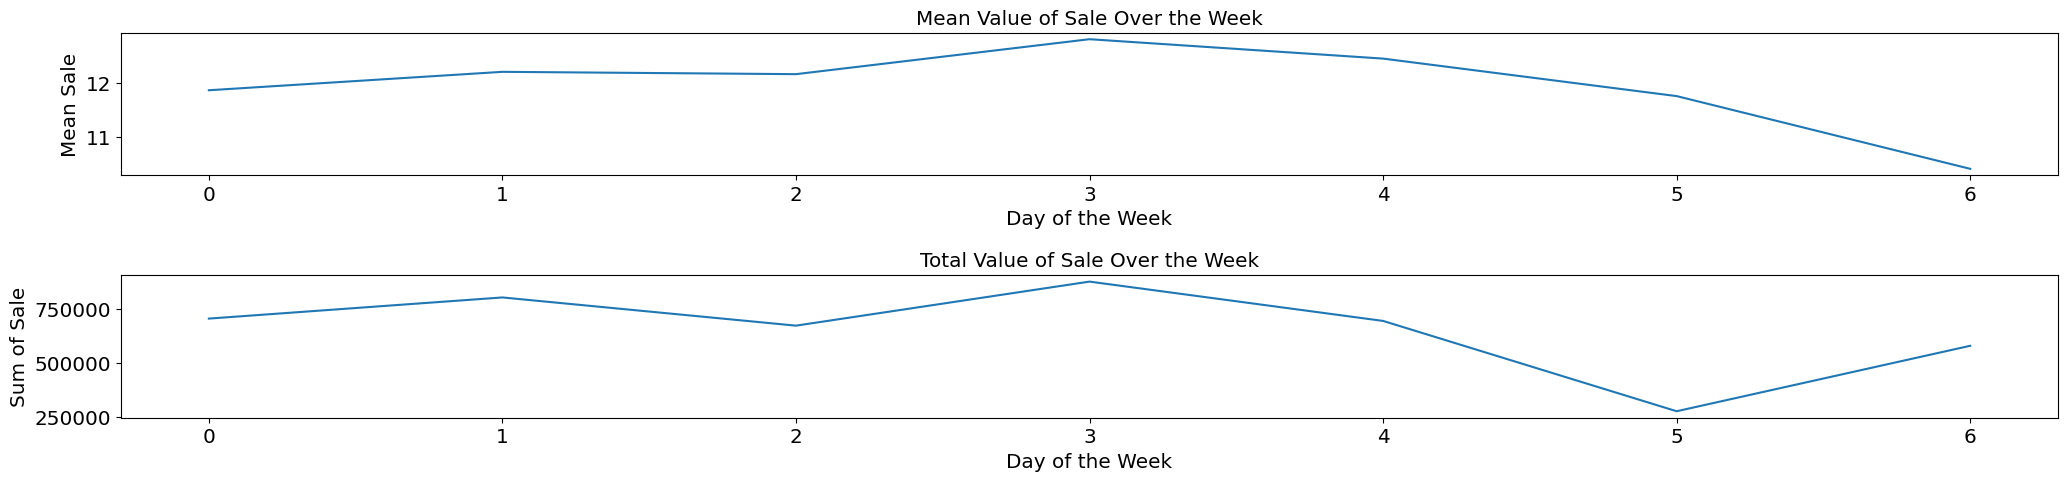

In [1072]:
# Set up a grid of plots
fig = plt.figure(figsize=(25, 5))
fig_dims = (2, 1)
fig.subplots_adjust(hspace=0.7)

# Plot mean sales
plt.subplot2grid(fig_dims, (0, 0))
mean_sales = df2['Sale_per_Qta'].groupby(df2.index.weekday).mean().plot()
plt.title('Mean Value of Sale Over the Week', fontsize='x-large')
plt.xlabel('Day of the Week', fontsize='x-large')
plt.ylabel('Mean Sale', fontsize='x-large')
plt.tick_params(labelsize='x-large')

# Plot total sales
plt.subplot2grid(fig_dims, (1, 0))
total_sales = df2['Sale_per_Qta'].groupby(df2.index.weekday).sum().plot()
plt.title('Total Value of Sale Over the Week', fontsize='x-large')
plt.xlabel('Day of the Week', fontsize='x-large')
plt.ylabel('Sum of Sale', fontsize='x-large')
plt.tick_params(labelsize='x-large')

plt.show()

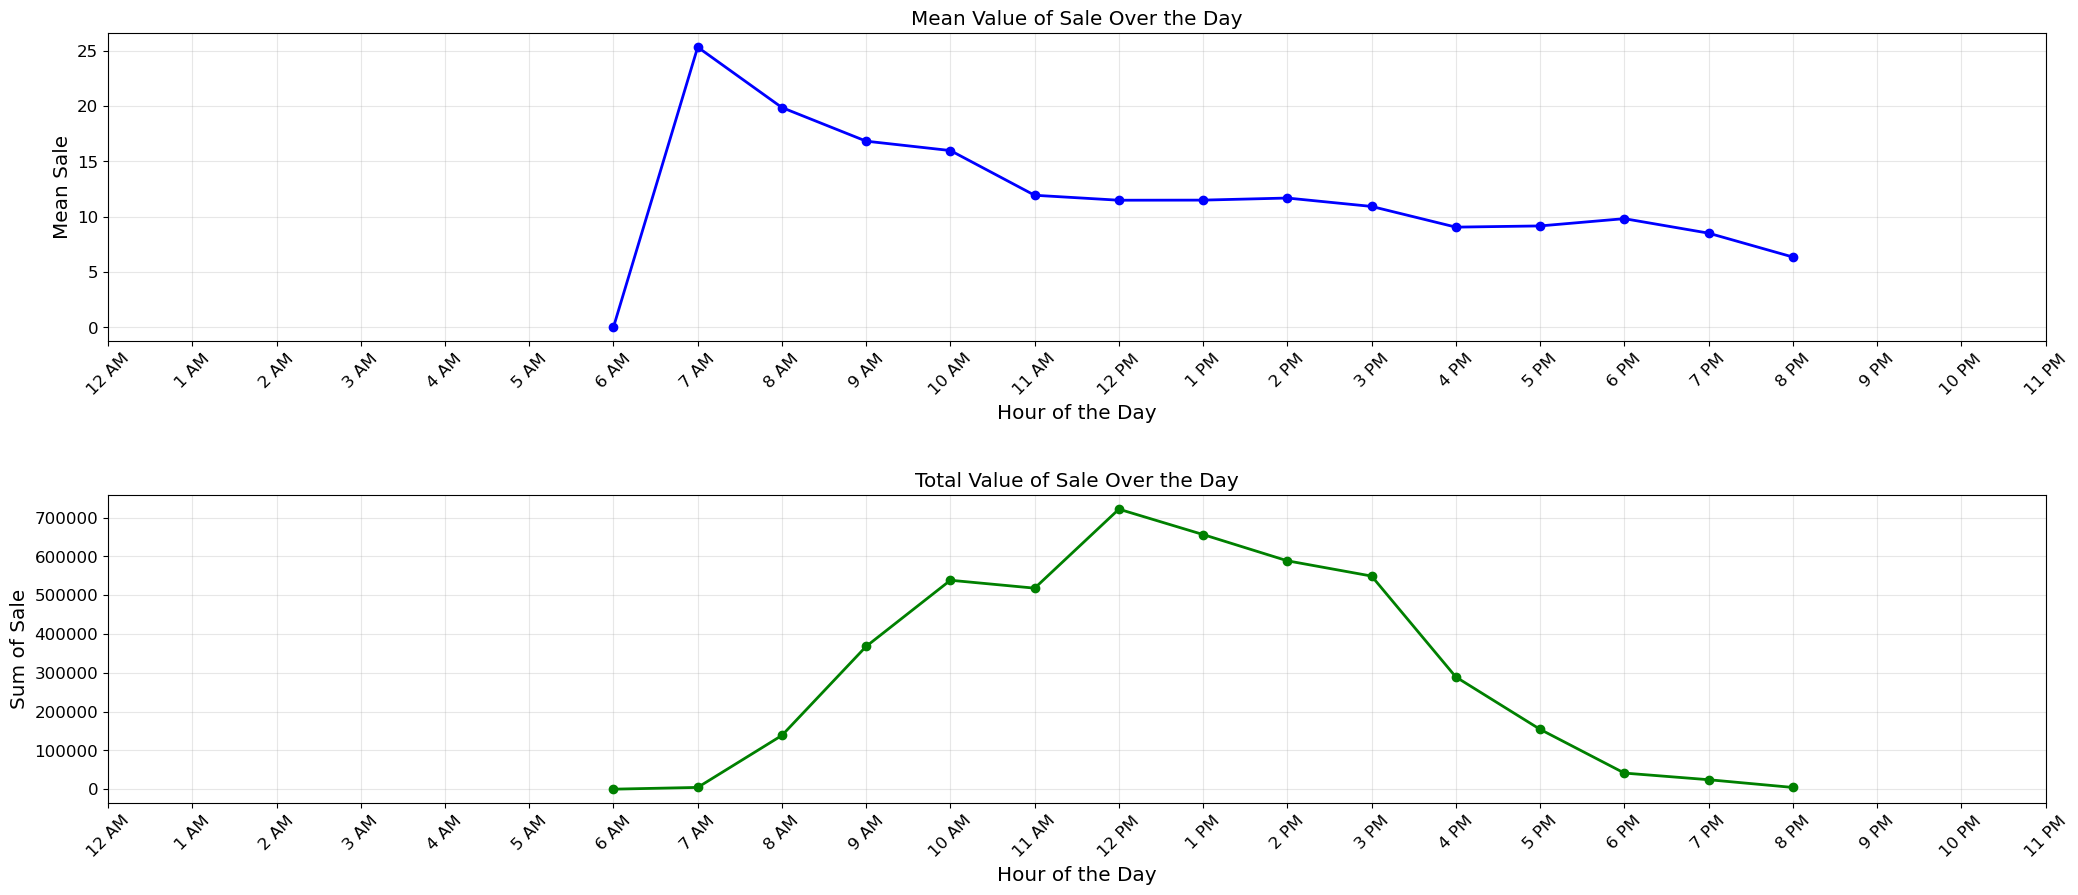

In [1073]:
# Set up a grid of plots
fig = plt.figure(figsize=(25, 10)) 
fig_dims = (2, 1)
fig.subplots_adjust(hspace=0.5)  

# Prepare 12-hour format labels
hour_labels = [f'{hour % 12 if hour % 12 != 0 else 12} {"AM" if hour < 12 else "PM"}' for hour in range(24)]

# Plot mean sales
plt.subplot2grid(fig_dims, (0, 0))
mean_sales = df2['Sale_per_Qta'].groupby(df2.index.hour).mean()
mean_sales.plot(color='blue', marker='o', linestyle='-', linewidth=2)
plt.title('Mean Value of Sale Over the Day', fontsize='x-large')
plt.xlabel('Hour of the Day', fontsize='x-large')
plt.ylabel('Mean Sale', fontsize='x-large')
plt.grid(alpha=0.3)  # Added grid for better readability
plt.xticks(range(24), hour_labels, rotation=45, fontsize='large')  
plt.tick_params(labelsize='large')

# Plot total sales
plt.subplot2grid(fig_dims, (1, 0))
total_sales = df2['Sale_per_Qta'].groupby(df2.index.hour).sum()
total_sales.plot(color='green', marker='o', linestyle='-', linewidth=2)
plt.title('Total Value of Sale Over the Day', fontsize='x-large')
plt.xlabel('Hour of the Day', fontsize='x-large')
plt.ylabel('Sum of Sale', fontsize='x-large')
plt.grid(alpha=0.3)  
plt.xticks(range(24), hour_labels, rotation=45, fontsize='large')  
plt.tick_params(labelsize='large')

plt.show()

### Observations

- The **high mean** but **low total sales values** in the early morning indicate that there are relatively few purchases during the first hours of the store's activity, but these purchases tend to be of higher value.

- The **medium mean** coupled with **high total sales values** around the central hours of the day suggests that this period is characterized by a higher volume of transactions, with each purchase being medium to small in value.


#### Analyzing Customer Distribution by Country
- We aim to display the number of customers in the UK compared to other countries and further break down the customer count for each non-UK country.

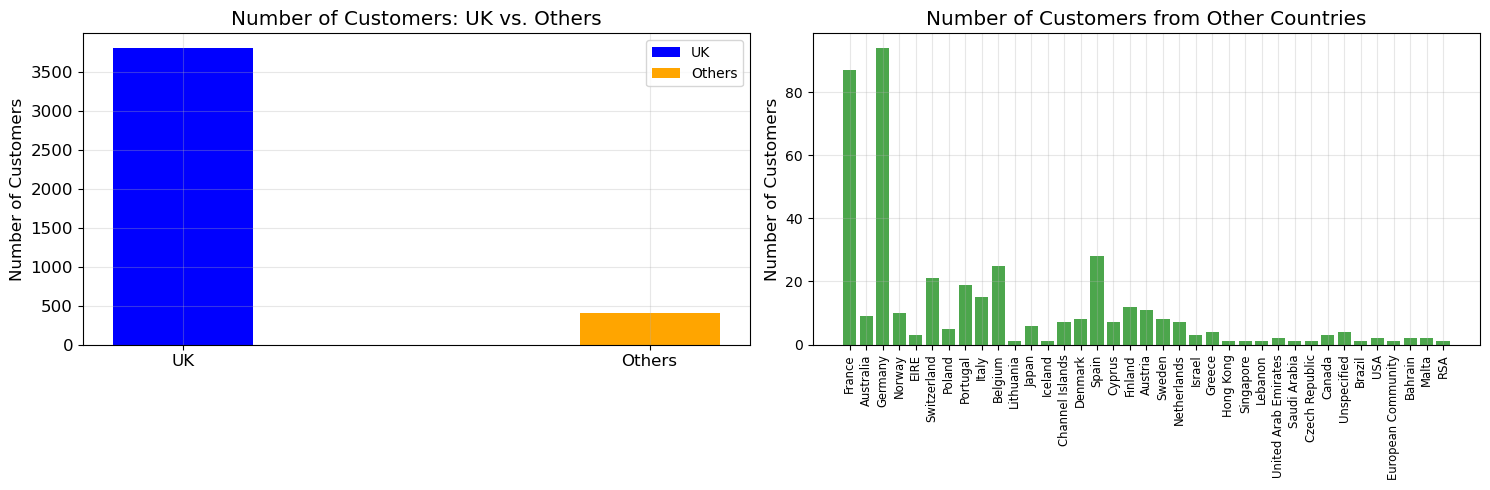

In [1074]:
# Separate UK and non-UK customers
# Count the number of customers from the UK and other countries
uk_cust_count = len(df[df.CustomerCountry == 'United Kingdom'].CustomerID.unique())
others_cust_count = len(df[df.CustomerCountry != 'United Kingdom'].CustomerID.unique())

# Visualize the number of customers in the UK vs. other countries
width = 0.3
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))  # Two subplots for clear separation
fig.subplots_adjust(wspace=0.4)  # Add space between subplots

# Plot UK vs. Other customers
axs[0].bar([0], [uk_cust_count], width=width, label='UK', color='blue')
axs[0].bar([1], [others_cust_count], width=width, label='Others', color='orange')
axs[0].set_xticks([0, 1])
axs[0].set_xticklabels(['UK', 'Others'], fontsize='large')
axs[0].set_title('Number of Customers: UK vs. Others', fontsize='x-large')
axs[0].set_ylabel('Number of Customers', fontsize='large')
axs[0].tick_params(axis='y', labelsize='large')
axs[0].legend(fontsize='medium')
axs[0].grid(alpha=0.3)

# Plot customers from other countries
non_uk_countries = df[df.CustomerCountry != 'United Kingdom'].CustomerCountry.unique()
customer_counts = [
    len(df[df.CustomerCountry == country].CustomerID.unique()) for country in non_uk_countries
]

axs[1].bar(non_uk_countries, customer_counts, color='green', alpha=0.7)
axs[1].set_xticks(range(len(non_uk_countries)))
axs[1].set_xticklabels(non_uk_countries, rotation=90, fontsize='small')
axs[1].set_title('Number of Customers from Other Countries', fontsize='x-large')
axs[1].set_ylabel('Number of Customers', fontsize='large')
axs[1].grid(alpha=0.3)


plt.tight_layout()
plt.show()

#### Analyzing Average Sale_per_Qta per CustomerCountry
-  **Objective**: Compute and visualize the average Sale_per_Qta for customers from each country.

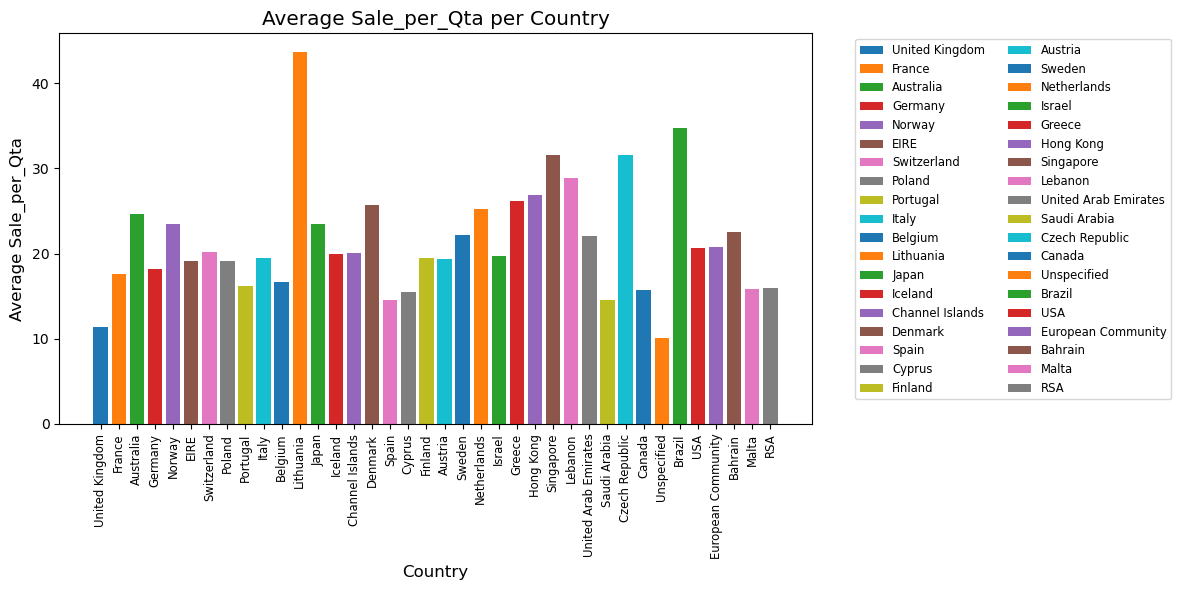

In [1075]:
# Extract unique countries
countries = df.CustomerCountry.unique()


fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(12, 6))


for i, country in enumerate(countries):
    mean_sale = df[df.CustomerCountry == country].Sale_per_Qta.mean()  # Calculate average
    axs.bar(i, mean_sale, label=country)  # Plot bar for each country

axs.set_title('Average Sale_per_Qta per Country', fontsize='x-large')
axs.set_xlabel('Country', fontsize='large')
axs.set_ylabel('Average Sale_per_Qta', fontsize='large')
axs.set_xticks(range(len(countries)))
axs.set_xticklabels(countries, rotation=90, fontsize='small')
axs.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize='small') 

plt.tight_layout()
plt.show()

# Creating a New Dataset: Customers

### Initial Setup and Customer DataFrame Creation

In [1076]:
# Creating the base DataFrame for customers
unique_customer_ids = df['CustomerID'].unique()
customer_data = pd.DataFrame(unique_customer_ids)
customer_data.set_index(0, inplace=True)
customer_data.index.names = ['CustomerID']

# Create a copy of the customer DataFrame for categorical attributes
customer_data_categorical = customer_data.copy()

### Numerical Attributes - Purchasing Behavior

In [1077]:
# Total number of items purchased by a customer
total_items_purchased = df[df.Qta >= 0]['Qta'].groupby(df['CustomerID']).sum()
customer_data['TotalItemsPurchased'] = total_items_purchased

# Number of distinct items purchased by a customer
distinct_items_purchased = df[df.Qta >= 0]['ProdID'].groupby(df['CustomerID']).unique().apply(len)
customer_data['DistinctItemsPurchased'] = distinct_items_purchased

# Maximum number of items purchased in a single session
max_items_single_session = df[df.Qta >= 0].groupby(['CustomerID', 'BasketID']).Qta.sum().max(level='CustomerID')
customer_data['MaxItemsSingleSession'] = max_items_single_session

# Average number of items purchased in a session
avg_items_per_session = df[df.Qta >= 0].groupby(['CustomerID', 'BasketID']).Qta.sum().mean(level='CustomerID')
customer_data['AvgItemsPerSession'] = avg_items_per_session

# Total number of items refunded
total_items_refunded = df[df.Qta < 0]['Qta'].groupby(df['CustomerID']).sum()
customer_data['TotalItemsRefunded'] = total_items_refunded

### Shannon's Entropy - Behavioral Diversity
- We used Shannon's Entropy to understand how different or random customer behavior is. It helps us measure:
    - **Product Choices**: Whether customers buy a lot of different products or stick to just a few.
    - **Shopping Habits**: How consistent or varied their shopping days, times, or sessions are.
    - **Behavior Patterns**: High entropy means customers are unpredictable and diverse, while low entropy means they are more predictable and focused.

In [1078]:
# Shannon's Entropy for products
def calculate_shannon_entropy(values):
    m = len(values)
    counts = collections.Counter(values)
    entropy = 0
    for key in counts:
        p_i = counts[key] / float(m)
        entropy += p_i * (math.log(p_i, 2))
    return -entropy if entropy != 0 else 0

# Shannon's Entropy for purchased products
product_entropy = df[df.Qta >= 0].groupby('CustomerID').ProdID.apply(calculate_shannon_entropy)
customer_data['ProductEntropy'] = product_entropy

# Shannon's Entropy for shopping sessions
session_entropy = df.groupby('CustomerID').BasketID.apply(calculate_shannon_entropy)
customer_data['SessionEntropy'] = session_entropy

# Shannon's Entropy for weekdays
weekday_entropy = df.copy()
weekday_entropy['BasketDate'] = weekday_entropy.BasketDate.dt.day_name(locale='English')
weekday_entropy = weekday_entropy.groupby('CustomerID').BasketDate.apply(calculate_shannon_entropy)
customer_data['WeekdayEntropy'] = weekday_entropy

# Shannon's Entropy for months
month_entropy = df.copy()
month_entropy['BasketDate'] = month_entropy.BasketDate.dt.month_name(locale='English')
month_entropy = month_entropy.groupby('CustomerID').BasketDate.apply(calculate_shannon_entropy)
customer_data['MonthEntropy'] = month_entropy

### Numerical Attributes - Spending Behavior

In [1079]:
# Total amount spent by each customer
total_amount_spent = df[df.Qta >= 0].groupby(df['CustomerID']).Sale_per_Qta.sum()
customer_data['TotalAmountSpent'] = total_amount_spent

# Total amount refunded by each customer
total_amount_refunded = df[df.Qta < 0].groupby(df['CustomerID']).Sale_per_Qta.sum()
customer_data['TotalAmountRefunded'] = total_amount_refunded

# Maximum amount spent in a single session
max_amount_single_session = df[df.Qta >= 0].groupby(['CustomerID', 'BasketID']).Sale_per_Qta.sum().max(level='CustomerID')
customer_data['MaxAmountSingleSession'] = max_amount_single_session

# Average amount spent in a session
avg_amount_per_session = df[df.Qta >= 0].groupby(['CustomerID', 'BasketID']).Sale_per_Qta.sum().mean(level='CustomerID')
customer_data['AvgAmountPerSession'] = avg_amount_per_session

In [1080]:
# Final cleanup
customer_data = customer_data.fillna(0)
customer_data['TotalItemsRefunded'] = customer_data['TotalItemsRefunded'].apply(abs)
customer_data = customer_data.astype({
    "TotalItemsPurchased": 'int',
    "DistinctItemsPurchased": 'int',
    "MaxItemsSingleSession": 'int',
    "TotalItemsRefunded": 'int',
    "TotalAmountSpent": 'float',
    "TotalAmountRefunded": 'float',
    "MaxAmountSingleSession": 'float',
    "AvgAmountPerSession": 'float'
})

In [1081]:
customer_data

,TotalItemsPurchased,DistinctItemsPurchased,MaxItemsSingleSession,AvgItemsPerSession,TotalItemsRefunded,ProductEntropy,SessionEntropy,WeekdayEntropy,MonthEntropy,TotalAmountSpent,TotalAmountRefunded,MaxAmountSingleSession,AvgAmountPerSession
CustomerID,,,,,,,,,,,,,
17850.00,1642,19,134,48.29,5,4.19,4.63,0.92,0.92,4384.59,-9.46,394.16,128.96
13047.00,1269,89,301,141.00,1,6.25,2.92,1.95,2.23,2535.97,-2.95,440.43,281.77
12583.00,3053,103,362,203.53,0,6.36,3.82,2.58,2.99,5283.29,0.00,737.66,352.22
14688.00,2192,133,248,115.37,7,6.72,4.08,2.14,3.03,3201.44,-9.97,373.22,168.50
17809.00,313,28,204,62.60,0,4.81,1.74,1.38,1.74,741.05,0.00,560.40,148.21
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13436.00,69,8,69,69.00,0,3.00,0.00,0.00,0.00,113.54,0.00,113.54,113.54
15520.00,194,17,194,194.00,0,4.09,0.00,0.00,0.00,320.70,0.00,320.70,320.70
13298.00,24,1,24,24.00,0,0.00,0.00,0.00,0.00,90.00,0.00,90.00,90.00


#### Spending Behavior - Temporal Analysis

In [1082]:
# Maximum amount spent in a week
df_with_weeks = df.copy()
df_with_weeks['BasketDate'] = df_with_weeks['BasketDate'].dt.week
max_weekly_spending = df_with_weeks[df.Qta >= 0].groupby(['CustomerID', 'BasketDate']).Sale_per_Qta.sum().max(level='CustomerID')
customer_data['MaxWeeklySpending'] = max_weekly_spending

# Average amount spent in a week
avg_weekly_spending = df_with_weeks[df.Qta >= 0].groupby(['CustomerID', 'BasketDate']).Sale_per_Qta.sum().mean(level='CustomerID')
customer_data['AvgWeeklySpending'] = avg_weekly_spending

# Maximum amount spent in a month
df_with_months = df.copy()
df_with_months['BasketDate'] = df_with_months['BasketDate'].dt.month
max_monthly_spending = df_with_months[df.Qta >= 0].groupby(['CustomerID', 'BasketDate']).Sale_per_Qta.sum().max(level='CustomerID')
customer_data['MaxMonthlySpending'] = max_monthly_spending

# Average amount spent in a month
avg_monthly_spending = df_with_months[df.Qta >= 0].groupby(['CustomerID', 'BasketDate']).Sale_per_Qta.sum().mean(level='CustomerID')
customer_data['AvgMonthlySpending'] = avg_monthly_spending

#### Shopping Session Count and Final Summary

In [1083]:
# Number of shopping sessions
total_shopping_sessions = df['BasketID'].groupby(df['CustomerID']).count()
customer_data['TotalShoppingSessions'] = total_shopping_sessions

# Final cleanup and summary
customer_data = customer_data.fillna(0)
customer_data['TotalItemsRefunded'] = customer_data['TotalItemsRefunded'].apply(abs)
customer_data = customer_data.astype({
    "TotalItemsPurchased": 'int',
    "DistinctItemsPurchased": 'int',
    "MaxItemsSingleSession": 'int',
    "TotalItemsRefunded": 'int'
})

# Display the final dataset
customer_data

,TotalItemsPurchased,DistinctItemsPurchased,MaxItemsSingleSession,AvgItemsPerSession,TotalItemsRefunded,ProductEntropy,SessionEntropy,WeekdayEntropy,MonthEntropy,TotalAmountSpent,TotalAmountRefunded,MaxAmountSingleSession,AvgAmountPerSession,MaxWeeklySpending,AvgWeeklySpending,MaxMonthlySpending,AvgMonthlySpending,TotalShoppingSessions
CustomerID,,,,,,,,,,,,,,,,,,
17850.00,1642,19,134,48.29,5,4.19,4.63,0.92,0.92,4384.59,-9.46,394.16,128.96,3182.32,2192.30,3182.32,2192.30,271
13047.00,1269,89,301,141.00,1,6.25,2.92,1.95,2.23,2535.97,-2.95,440.43,281.77,679.33,422.66,771.90,507.19,147
12583.00,3053,103,362,203.53,0,6.36,3.82,2.58,2.99,5283.29,0.00,737.66,352.22,737.66,406.41,1074.75,587.03,204
14688.00,2192,133,248,115.37,7,6.72,4.08,2.14,3.03,3201.44,-9.97,373.22,168.50,634.64,177.86,764.98,291.04,266
17809.00,313,28,204,62.60,0,4.81,1.74,1.38,1.74,741.05,0.00,560.40,148.21,560.40,148.21,560.40,148.21,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13436.00,69,8,69,69.00,0,3.00,0.00,0.00,0.00,113.54,0.00,113.54,113.54,113.54,113.54,113.54,113.54,8
15520.00,194,17,194,194.00,0,4.09,0.00,0.00,0.00,320.70,0.00,320.70,320.70,320.70,320.70,320.70,320.70,17
13298.00,24,1,24,24.00,0,0.00,0.00,0.00,0.00,90.00,0.00,90.00,90.00,90.00,90.00,90.00,90.00,1


### **Index**
- **`CustomerID`**  
  - Unique identifier for each customer in the dataset.
---
### **Columns Description**

1. **`TotalItemsPurchased`**  
   - Total number of items purchased by the customer (positive quantities only).

2. **`DistinctItemsPurchased`**  
   - Number of unique items (distinct product IDs) purchased by the customer.

3. **`MaxItemsSingleSession`**  
   - Maximum number of items purchased by the customer in a single shopping session.

4. **`AvgItemsPerSession`**  
   - Average number of items purchased by the customer per shopping session.

5. **`TotalItemsRefunded`**  
   - Total number of items refunded by the customer (negative quantities).

6. **`ProductEntropy`**  
   - Shannon's Entropy for the variety of products purchased by the customer, measuring product diversity.

7. **`SessionEntropy`**  
   - Shannon's Entropy for the customer's shopping sessions, measuring the variability of sessions.

8. **`WeekdayEntropy`**  
   - Shannon's Entropy for the days of the week the customer shops, measuring day variability.

9. **`MonthEntropy`**  
   - Shannon's Entropy for the months of the year the customer shops, measuring month variability.

10. **`TotalAmountSpent`**  
    - Total amount spent by the customer (positive transactions only).

11. **`TotalAmountRefunded`**  
    - Total amount refunded to the customer (negative transactions).

12. **`MaxAmountSingleSession`**  
    - Maximum amount spent by the customer in a single shopping session.

13. **`AvgAmountPerSession`**  
    - Average amount spent by the customer per shopping session.

14. **`MaxWeeklySpending`**  
    - Maximum amount spent by the customer in a single week.

15. **`AvgWeeklySpending`**  
    - Average amount spent by the customer per week.

16. **`MaxMonthlySpending`**  
    - Maximum amount spent by the customer in a single month.

17. **`AvgMonthlySpending`**  
    - Average amount spent by the customer per month.

18. **`TotalShoppingSessions`**  
    - Total number of shopping sessions by the customer.

## Customers: Categorical Attributes

### 1. **Country: Majority Country of Transactions**
- **Purpose:** Adds a column representing the majority country for each customer.

In [1084]:
# Group by CustomerID and get unique CustomerCountry values
customer_countries = df.groupby(by=['CustomerID']).CustomerCountry.unique()

# Create a DataFrame with the first country for each customer
customer_countries_df = pd.DataFrame(customer_countries.apply(lambda x: x[0]))

# Add the 'Country' column to the categorical dataset
customer_data_categorical['Country'] = customer_countries_df

#### 2. **Fav_Weekday: Day of Maximum Spending**
- **Purpose:** Adds a column for the weekday when the customer spends the most.

In [1085]:
# Create a copy of the original DataFrame to work with weekdays
transactions_with_weekdays = df.copy()

# Convert 'BasketDate' to the weekday name
transactions_with_weekdays['BasketDate'] = transactions_with_weekdays['BasketDate'].dt.day_name(locale='English')

# Maximum amount spent by a customer during a week
spending_per_weekday = transactions_with_weekdays.groupby(by=['CustomerID', 'BasketDate']).Sale_per_Qta.sum()

favorite_weekday = {}
for row in spending_per_weekday.iteritems():
    if row[0][0] not in favorite_weekday:
        favorite_weekday[row[0][0]] = row[0][1]

# Create a DataFrame from the favorite weekday dictionary
favorite_weekday_df = pd.DataFrame.from_dict(favorite_weekday, orient='index', columns=['Fav_Weekday'])

# Add the column to the categorical dataset
customer_data_categorical['Fav_Weekday'] = favorite_weekday_df

#### 3. **Fav_Month: Month of Maximum Spending**
- **Purpose:** Adds a column for the month when the customer spends the most.

In [1086]:
# Create a copy of the original DataFrame to work with months
transactions_with_months = df.copy()
transactions_with_months['BasketDate'] = transactions_with_months['BasketDate'].dt.month_name(locale='English')

# Maximum amount spent by a customer during a month
spending_per_month = transactions_with_months.groupby(by=['CustomerID', 'BasketDate']).Sale_per_Qta.sum()

favorite_month = {}
for row in spending_per_month.iteritems():
    if row[0][0] not in favorite_month:
        favorite_month[row[0][0]] = row[0][1]

# Create a DataFrame from the favorite month dictionary
favorite_month_df = pd.DataFrame.from_dict(favorite_month, orient='index', columns=['Fav_Month'])

# Add the column to the categorical dataset
customer_data_categorical['Fav_Month'] = favorite_month_df


### **Final `customer_data_categorical` DataFrame**
After adding these attributes, `customer_data_categorical` will contain the following columns:
1. **Country:** Majority country of the customer’s transactions.
2. **Fav_Weekday:** The weekday when the customer spends the most.
3. **Fav_Month:** The month when the customer spends the most.

In [1087]:
customer_data_categorical.head()

,Country,Fav_Weekday,Fav_Month
CustomerID,,,
17850.0,United Kingdom,Friday,February
13047.0,United Kingdom,Friday,April
12583.0,France,Friday,August
14688.0,United Kingdom,Friday,April
17809.0,United Kingdom,Friday,February


In [1088]:
customer_data.describe()

,TotalItemsPurchased,DistinctItemsPurchased,MaxItemsSingleSession,AvgItemsPerSession,TotalItemsRefunded,ProductEntropy,SessionEntropy,WeekdayEntropy,MonthEntropy,TotalAmountSpent,TotalAmountRefunded,MaxAmountSingleSession,AvgAmountPerSession,MaxWeeklySpending,AvgWeeklySpending,MaxMonthlySpending,AvgMonthlySpending,TotalShoppingSessions
count,4212.00,4212.00,4212.00,4212.00,4212.00,4212.00,4212.00,4212.00,4212.00,4212.00,4212.00,4212.00,4212.00,4212.00,4212.00,4212.00,4212.00,4212.00
mean,623.48,55.26,216.94,148.64,0.85,4.78,1.19,0.84,1.00,1092.81,-1.51,350.87,245.22,375.14,266.17,438.60,303.25,90.89
std,2596.10,85.69,201.71,131.39,17.63,1.73,1.18,0.81,0.97,6190.53,10.63,331.56,206.49,444.65,258.27,1023.08,564.27,897.37
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-244.18,0.00,0.00,0.00,0.00,0.00,0.00,1.00
25%,110.75,13.00,88.00,67.88,0.00,3.70,0.00,0.00,0.00,201.04,0.00,152.94,124.46,154.64,128.22,158.72,135.84,14.00
50%,271.50,31.00,168.00,116.63,0.00,4.91,0.99,0.90,0.95,460.72,0.00,274.45,200.19,281.21,214.46,295.34,234.16,35.00
75%,677.25,69.00,284.00,194.04,0.00,6.03,1.96,1.51,1.75,1110.36,0.00,430.22,308.66,458.68,327.50,519.91,365.93,86.00
max,149151.00,2857.00,2434.00,2434.00,1104.00,10.61,9.46,2.77,3.55,377973.02,0.00,4721.74,3559.36,16113.76,7268.71,57243.76,31497.75,57292.00




### Analyzing `Fav_Weekday` and `Fav_Month`**

- **Purpose:** Shows which weekdays are most popular for customer spending.
- **Insight:** Helps determine the busiest days to focus marketing efforts.
#### 1. **Fav_Weekday Distribution**

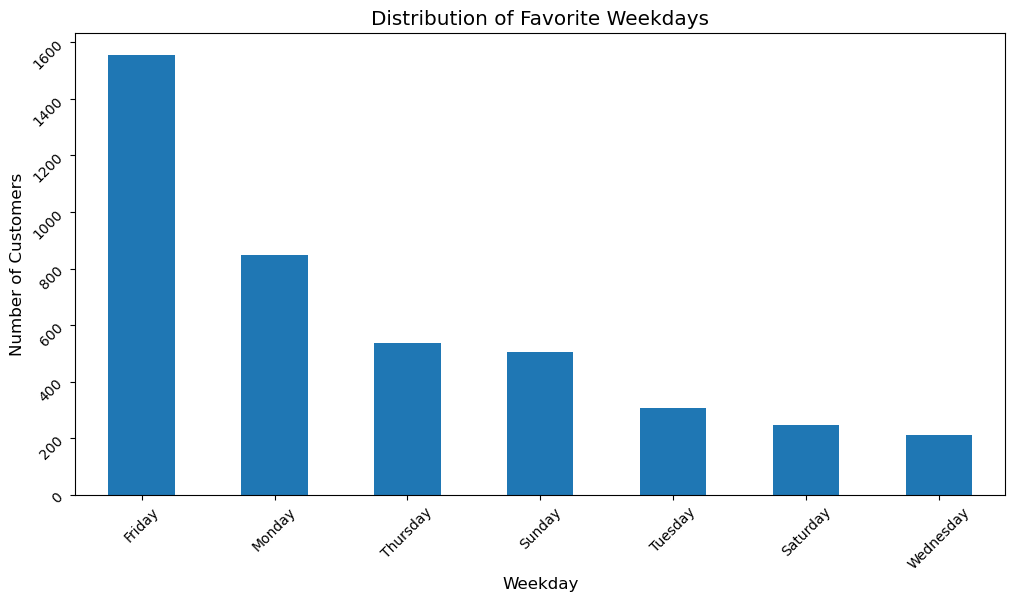

In [1089]:
# Analyzing distribution of favorite weekdays
fig, ax = plt.subplots(figsize=(12, 6))
customer_data_categorical['Fav_Weekday'].value_counts().plot(kind='bar', ax=ax)
ax.set_title('Distribution of Favorite Weekdays', fontsize='x-large')
ax.set_xlabel('Weekday', fontsize='large')
ax.set_ylabel('Number of Customers', fontsize='large')
ax.tick_params(labelrotation=45)
plt.show()

 **Favorite Weekdays:**
   - Identify which day of the week sees the highest customer spending. For example:
     - **Friday** might show the highest bar, indicating it’s the most popular day for shopping.
     - Less popular days (e.g., **Monday**) could indicate an opportunity to run promotions.

#### 2. **Fav_Month Distribution**
- **Purpose:** Identifies which months are most popular for customer spending.
- **Insight:** Useful for planning seasonal promotions and inventory.

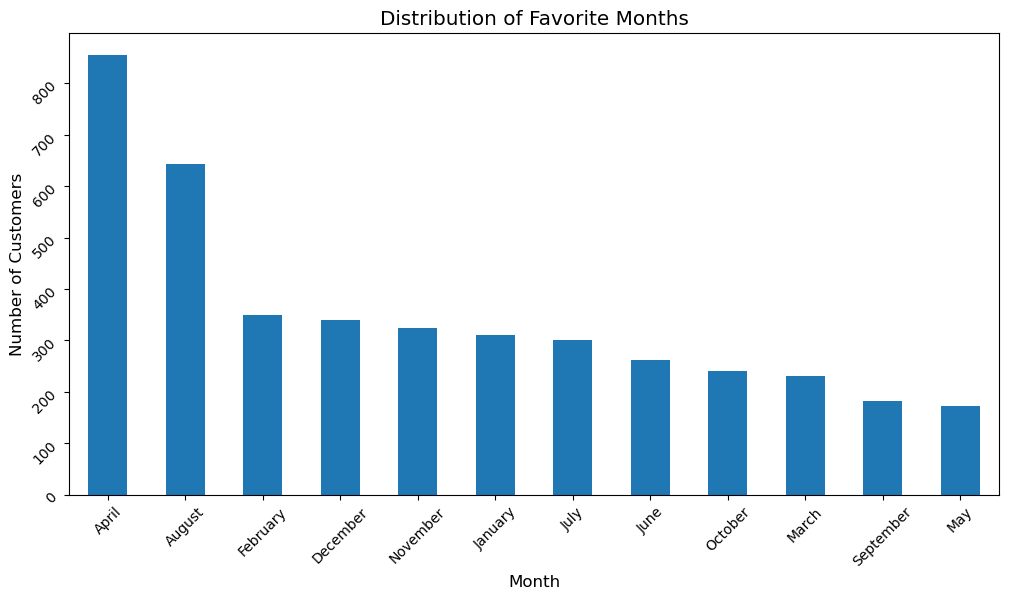

In [1090]:
# Analyzing distribution of favorite months
fig, ax = plt.subplots(figsize=(12, 6))
customer_data_categorical['Fav_Month'].value_counts().plot(kind='bar', ax=ax)
ax.set_title('Distribution of Favorite Months', fontsize='x-large')
ax.set_xlabel('Month', fontsize='large')
ax.set_ylabel('Number of Customers', fontsize='large')
ax.tick_params(labelrotation=45)
plt.show()

**Favorite Months:**
 - Most months show steady activity, but April and August stand out, while some months like May may need more attention for improvement., suggesting room for seasonal campaigns.

### Handling Outliers in the `Customers` Dataset

We can use the `iqr_values` function to identify outliers for each column and visualize them:

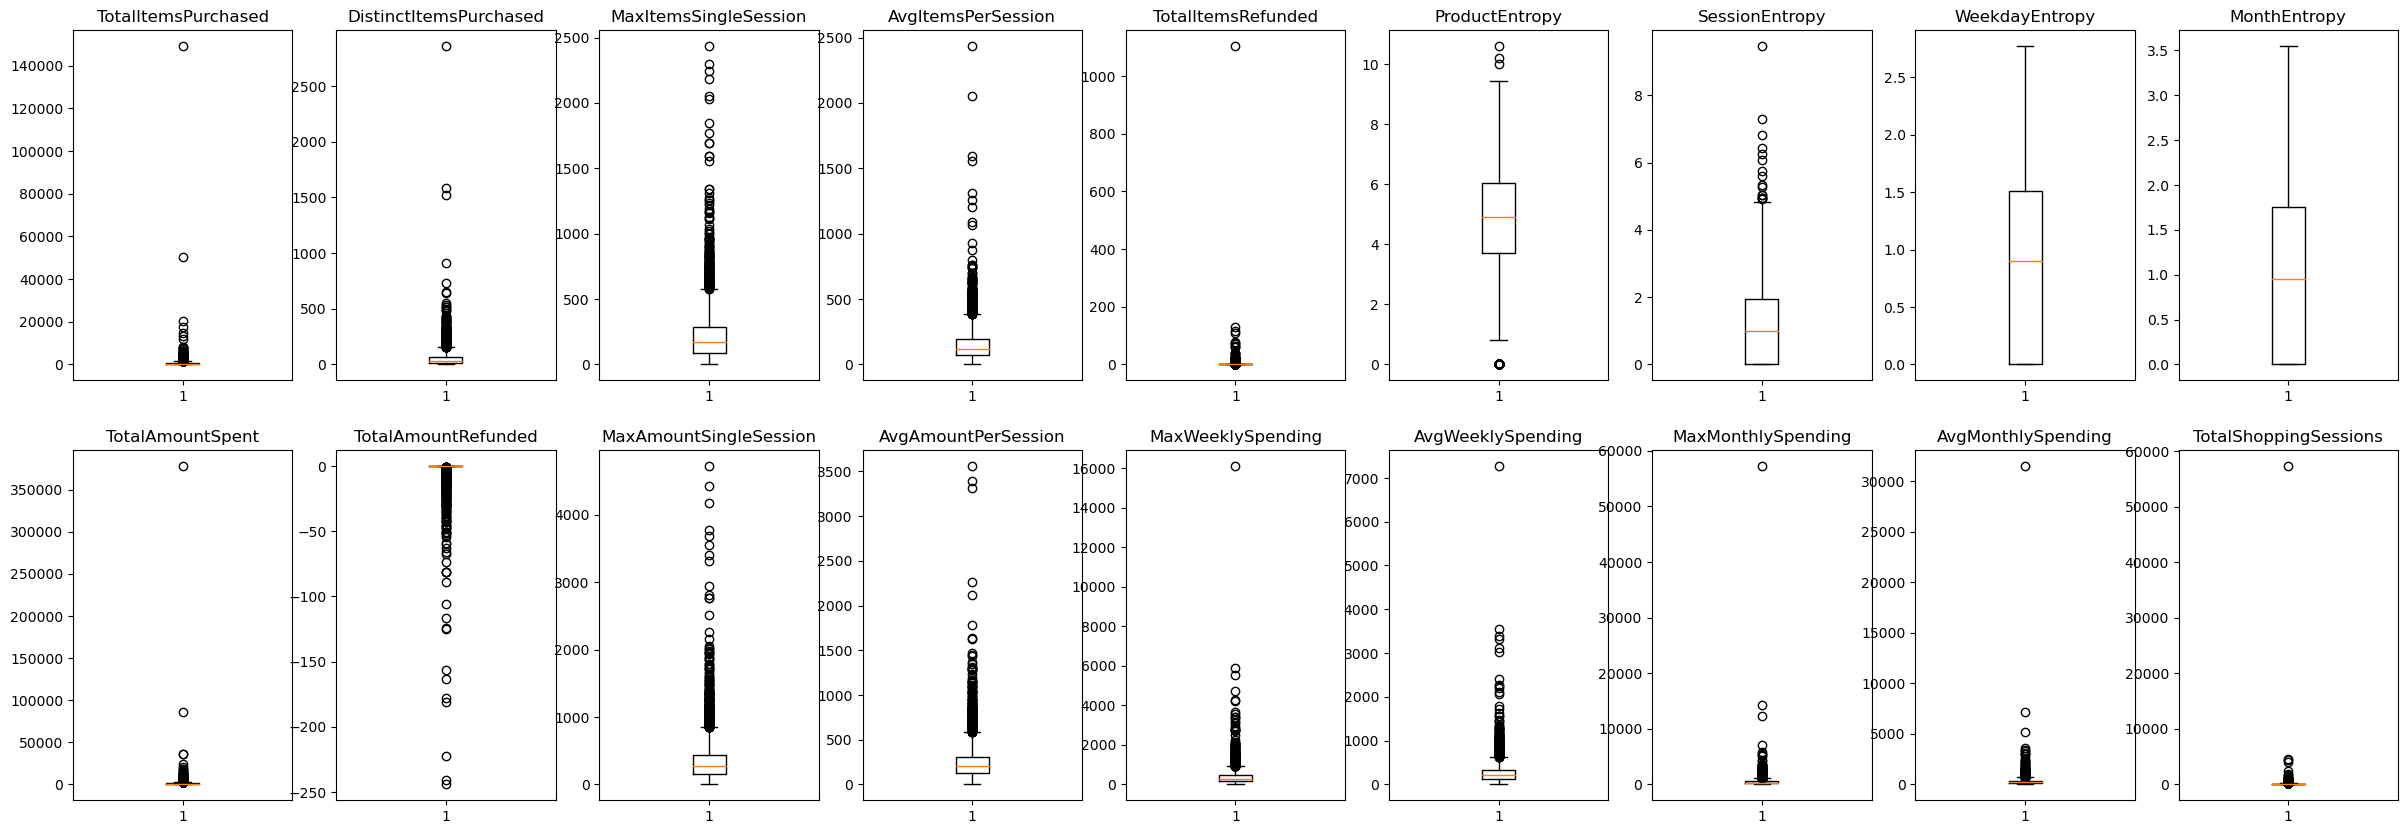

In [1091]:
# Visualizing outliers using boxplots
fig, axs = plt.subplots(nrows=2, ncols=9, figsize=(30, 10))
for i in range(len(customer_data.columns)):
    col_name = customer_data.columns[i]
    row_idx = int(i / 9)
    col_idx = i % 9
    axs[row_idx, col_idx].boxplot(customer_data[col_name])
    axs[row_idx, col_idx].set_title(col_name)
plt.show()

In [1092]:
# Creating a DataFrame for outliers
customer_outliers = pd.DataFrame(columns=customer_data.columns, index=customer_data.index)
customer_outliers.drop(customer_outliers.index, inplace=True)  # Drop all rows initially to start fresh

# Define the milder IQR-based function for outlier detection
def mild_iqr_values(s): 
    q1 = s.quantile(0.25)  # 25th percentile
    q3 = s.quantile(0.75)  # 75th percentile
    iqr = q3 - q1          # Interquartile range
    iqr_left = q1 - 3 * iqr  # Mild lower bound
    iqr_right = q3 + 3 * iqr  # Mild upper bound
    return iqr_left, iqr_right

# Loop through each column to detect outliers
for attribute in customer_data.columns:
    iqr_left, iqr_right = mild_iqr_values(customer_data[attribute])  # Compute IQR bounds
    # Append rows containing outliers to customer_outliers
    customer_outliers = customer_outliers.append(
        customer_data[(customer_data[attribute] < iqr_left) | (customer_data[attribute] > iqr_right)]
    )

# Display the outliers just identified
customer_outliers

,TotalItemsPurchased,DistinctItemsPurchased,MaxItemsSingleSession,AvgItemsPerSession,TotalItemsRefunded,ProductEntropy,SessionEntropy,WeekdayEntropy,MonthEntropy,TotalAmountSpent,TotalAmountRefunded,MaxAmountSingleSession,AvgAmountPerSession,MaxWeeklySpending,AvgWeeklySpending,MaxMonthlySpending,AvgMonthlySpending,TotalShoppingSessions
CustomerID,,,,,,,,,,,,,,,,,,
12583.00,3053,103,362,203.53,0,6.36,3.82,2.58,2.99,5283.29,0.00,737.66,352.22,737.66,406.41,1074.75,587.03,204
15311.00,7958,519,407,87.45,15,8.52,6.26,2.72,3.50,17376.23,-28.16,908.38,190.95,908.38,362.00,2715.28,1448.02,1896
17511.00,5266,150,507,188.07,30,6.81,4.78,2.43,3.28,12069.39,-65.90,939.13,431.05,1220.53,502.89,2771.88,1005.78,315
13408.00,4152,127,359,79.85,3,6.70,5.29,2.31,3.42,9182.15,-20.85,786.49,176.58,786.49,306.07,1217.67,765.18,259
13767.00,3108,42,171,86.33,0,4.75,5.02,2.52,3.26,7485.41,0.00,408.90,207.93,768.36,325.45,1237.12,680.49,265
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17813.00,663,265,497,132.60,0,7.97,1.51,1.09,1.51,1138.49,0.00,712.35,227.70,712.35,227.70,712.35,227.70,309
17509.00,3508,75,500,438.50,0,5.97,2.95,1.16,0.87,6069.24,0.00,898.14,758.65,4287.96,3034.62,4287.96,3034.62,364
14547.00,1992,181,544,249.00,0,7.29,2.70,1.31,1.67,3294.96,0.00,921.28,411.87,921.28,549.16,2070.50,823.74,317


In [1093]:
customer_outliers = customer_outliers.drop_duplicates()
customer_outliers

,TotalItemsPurchased,DistinctItemsPurchased,MaxItemsSingleSession,AvgItemsPerSession,TotalItemsRefunded,ProductEntropy,SessionEntropy,WeekdayEntropy,MonthEntropy,TotalAmountSpent,TotalAmountRefunded,MaxAmountSingleSession,AvgAmountPerSession,MaxWeeklySpending,AvgWeeklySpending,MaxMonthlySpending,AvgMonthlySpending,TotalShoppingSessions
CustomerID,,,,,,,,,,,,,,,,,,
12583.00,3053,103,362,203.53,0,6.36,3.82,2.58,2.99,5283.29,0.00,737.66,352.22,737.66,406.41,1074.75,587.03,204
15311.00,7958,519,407,87.45,15,8.52,6.26,2.72,3.50,17376.23,-28.16,908.38,190.95,908.38,362.00,2715.28,1448.02,1896
17511.00,5266,150,507,188.07,30,6.81,4.78,2.43,3.28,12069.39,-65.90,939.13,431.05,1220.53,502.89,2771.88,1005.78,315
13408.00,4152,127,359,79.85,3,6.70,5.29,2.31,3.42,9182.15,-20.85,786.49,176.58,786.49,306.07,1217.67,765.18,259
13767.00,3108,42,171,86.33,0,4.75,5.02,2.52,3.26,7485.41,0.00,408.90,207.93,768.36,325.45,1237.12,680.49,265
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16813.00,1118,237,181,111.80,0,7.61,3.18,1.44,2.83,1385.57,0.00,191.11,138.56,191.11,138.56,330.79,173.20,407
14178.00,1299,181,318,185.57,0,7.27,2.72,2.21,2.49,1446.49,0.00,320.10,206.64,320.10,206.64,410.87,241.08,305
18122.00,1043,225,297,173.83,0,7.56,2.43,2.20,2.43,1609.62,0.00,394.54,268.27,394.54,268.27,394.54,268.27,342


In [1094]:
customer_data = customer_data.drop(customer_outliers.index)
customer_data_categorical = customer_data_categorical.drop(customer_outliers.index)

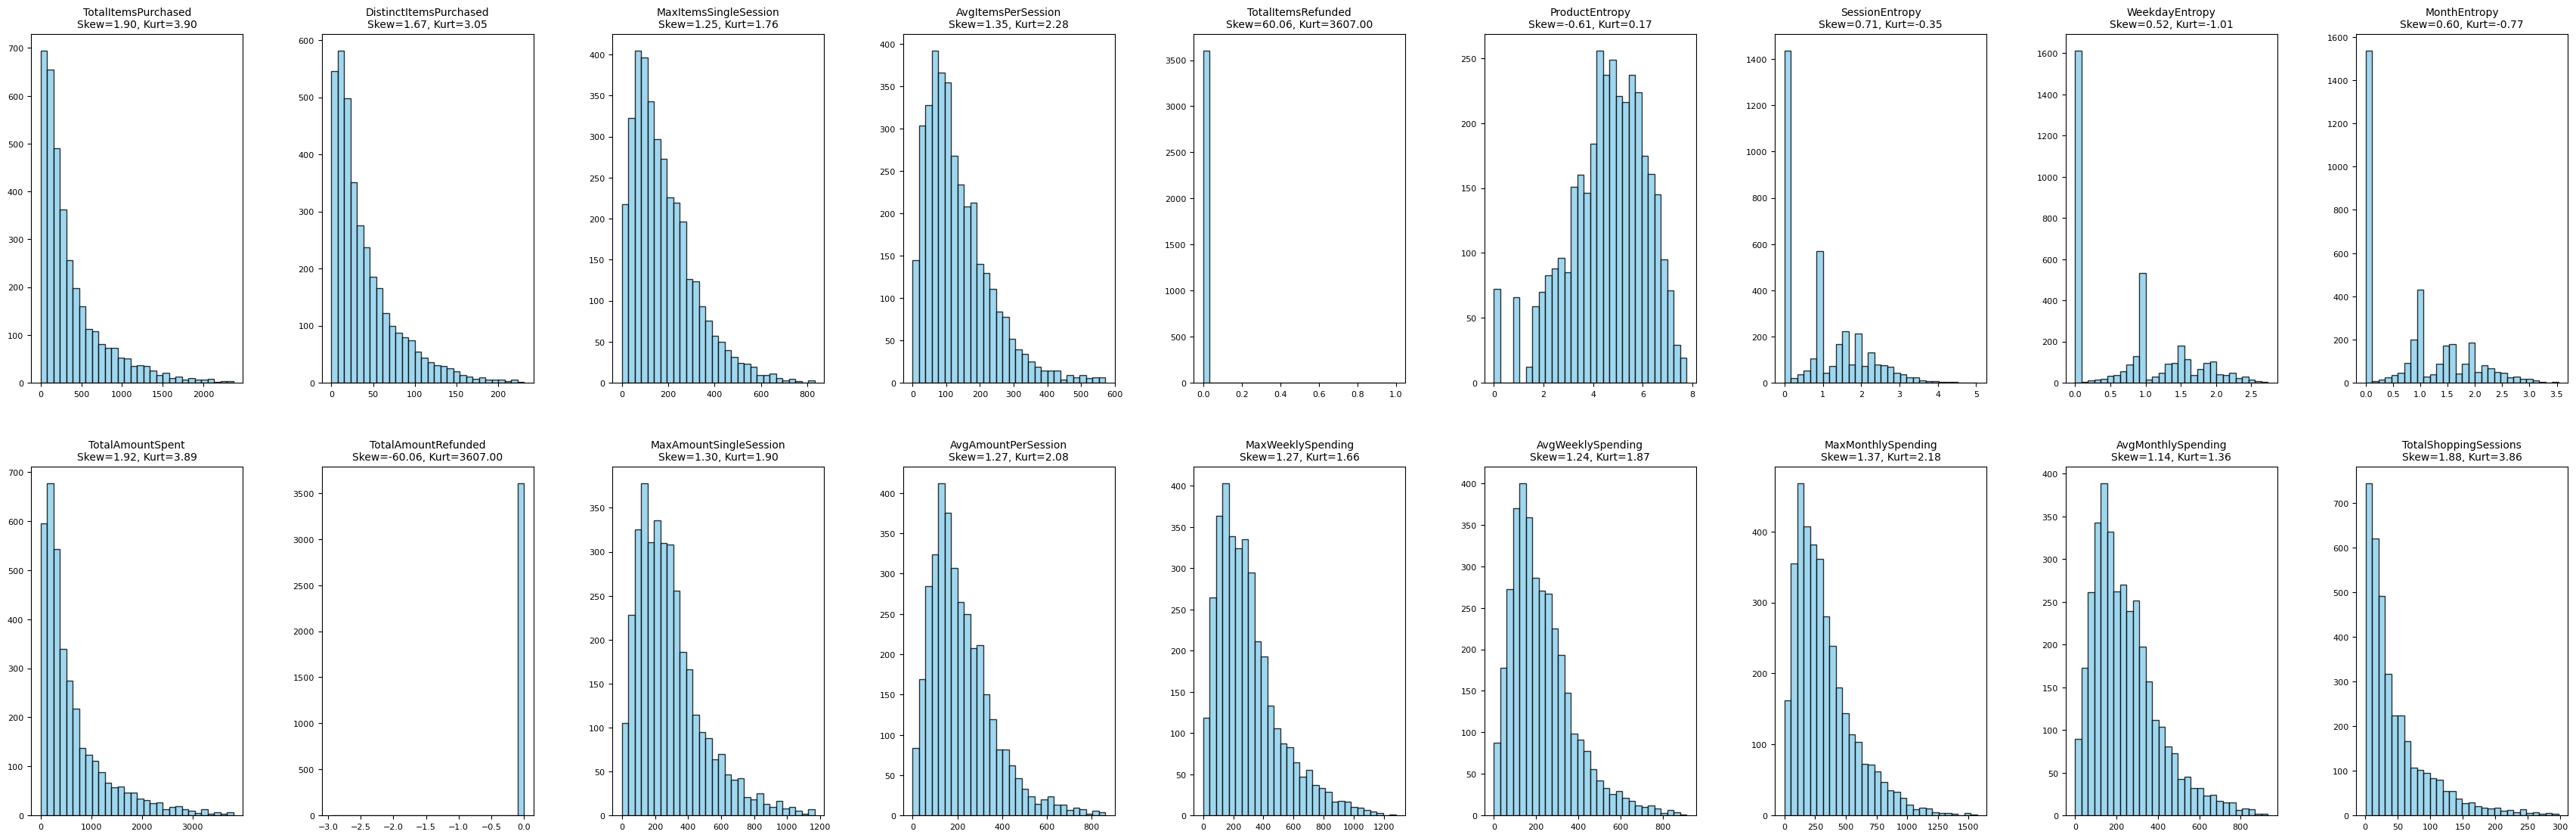

In [1095]:
# Plot distributions of the cleaned dataset with improved visualization
fig, axs = plt.subplots(nrows=2, ncols=9, figsize=(35, 12))  # Adjusted figure size for better visibility

for i in range(len(customer_data.columns)):
    col_name = customer_data.columns[i]
    row_idx = int(i / 9)
    col_idx = i % 9
    
    # Plot histogram for each column
    axs[row_idx][col_idx].hist(customer_data[col_name], bins=30, color='skyblue', alpha=0.8, edgecolor='black')
    
    # Set title with skewness and kurtosis
    axs[row_idx][col_idx].set_title(
        f"{col_name}\nSkew={customer_data[col_name].skew():.2f}, Kurt={customer_data[col_name].kurt():.2f}",
        fontsize=10
    )
    
    # Improve tick labels
    axs[row_idx][col_idx].tick_params(axis='both', labelsize=8)

# Add padding to avoid overlap
plt.tight_layout(pad=4.0)
plt.show()

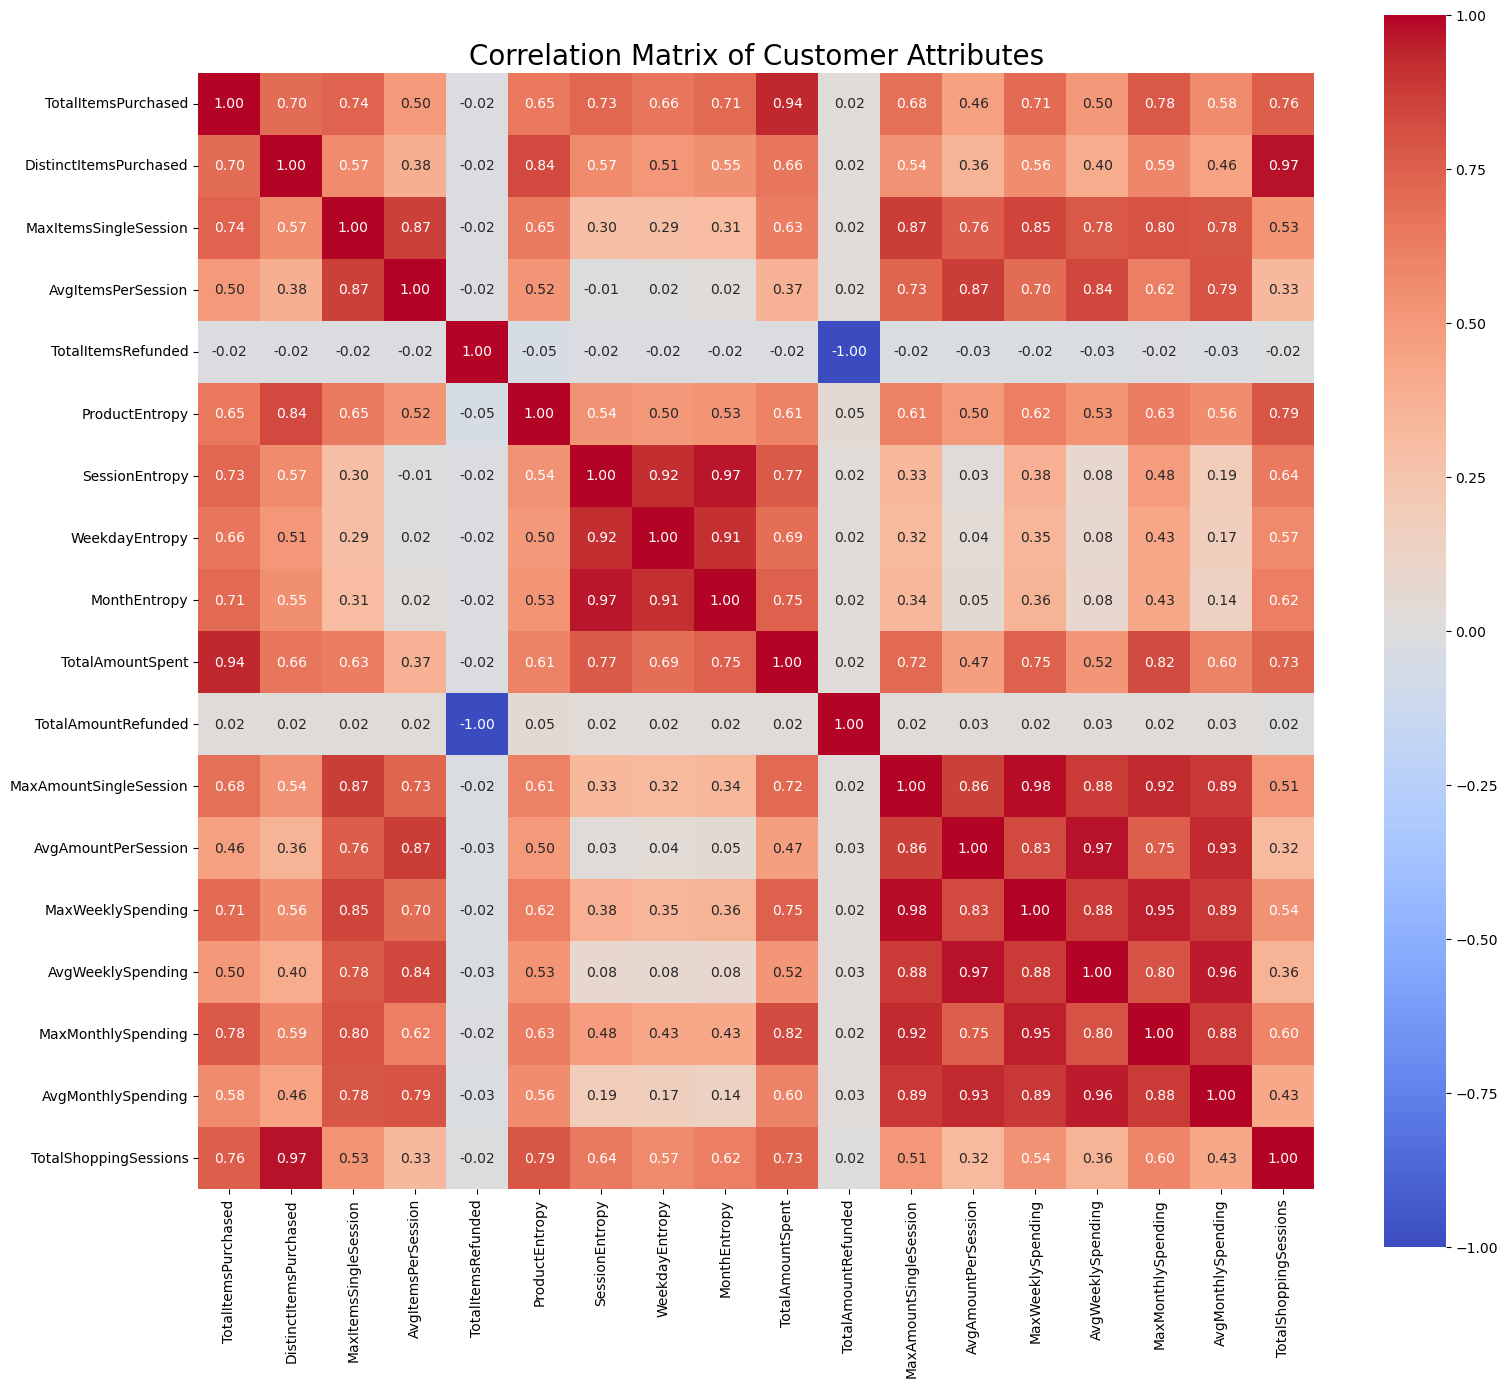

In [1096]:
# Compute correlation matrix
correlation_matrix = customer_data.corr()

# Plot the heatmap
plt.figure(figsize=(18, 16))
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    cbar=True, 
    square=True, 
    annot_kws={"size": 10}
)
plt.title('Correlation Matrix of Customer Attributes', fontsize=20)
plt.show()

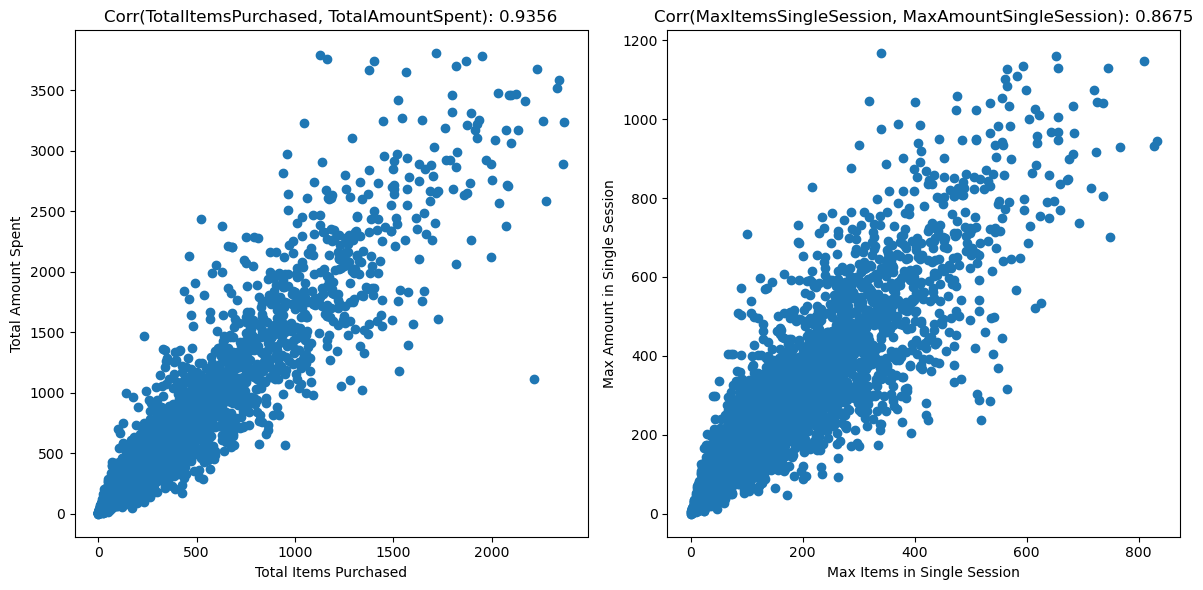

In [1098]:
# Plot the scatterplots for highly correlated attributes
f, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Scatterplot for TotalItemsPurchased vs TotalAmountSpent
axs[0].scatter(customer_data['TotalItemsPurchased'], customer_data['TotalAmountSpent'])
axs[0].set_title('Corr(TotalItemsPurchased, TotalAmountSpent): {:.4f}'.format(
    customer_data['TotalItemsPurchased'].corr(customer_data['TotalAmountSpent'])))
axs[0].set_xlabel('Total Items Purchased')
axs[0].set_ylabel('Total Amount Spent')

# Scatterplot for MaxItemsSingleSession vs MaxAmountSingleSession
axs[1].scatter(customer_data['MaxItemsSingleSession'], customer_data['MaxAmountSingleSession'])
axs[1].set_title('Corr(MaxItemsSingleSession, MaxAmountSingleSession): {:.4f}'.format(
    customer_data['MaxItemsSingleSession'].corr(customer_data['MaxAmountSingleSession'])))
axs[1].set_xlabel('Max Items in Single Session')
axs[1].set_ylabel('Max Amount in Single Session')

plt.tight_layout()
plt.show()


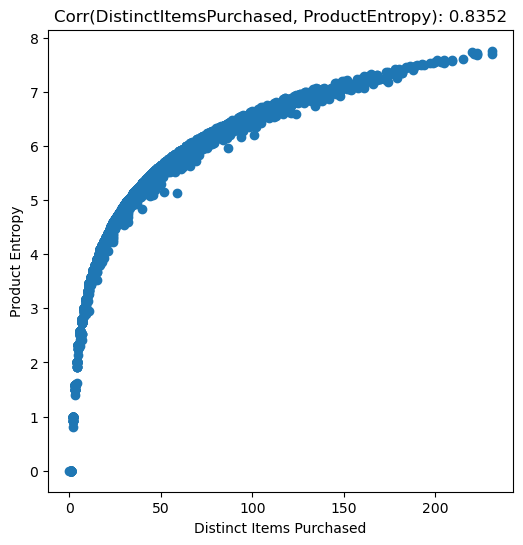

In [1099]:
# Plot the scatterplot for correlation between DistinctItemsPurchased and ProductEntropy
f, axs = plt.subplots(nrows=1, ncols=1, figsize=(6, 6))

# Scatterplot for DistinctItemsPurchased vs ProductEntropy
axs.scatter(customer_data['DistinctItemsPurchased'], customer_data['ProductEntropy'])
axs.set_title('Corr(DistinctItemsPurchased, ProductEntropy): {:.4f}'.format(
    customer_data['DistinctItemsPurchased'].corr(customer_data['ProductEntropy'])))
axs.set_xlabel('Distinct Items Purchased')
axs.set_ylabel('Product Entropy')

plt.show()

#### Observations:
1. A strong positive correlation is observed between Distinct Items Purchased and Product Entropy.
2. This suggests that customers who purchase a greater variety of items tend to have a more diverse and disordered purchasing behavior.

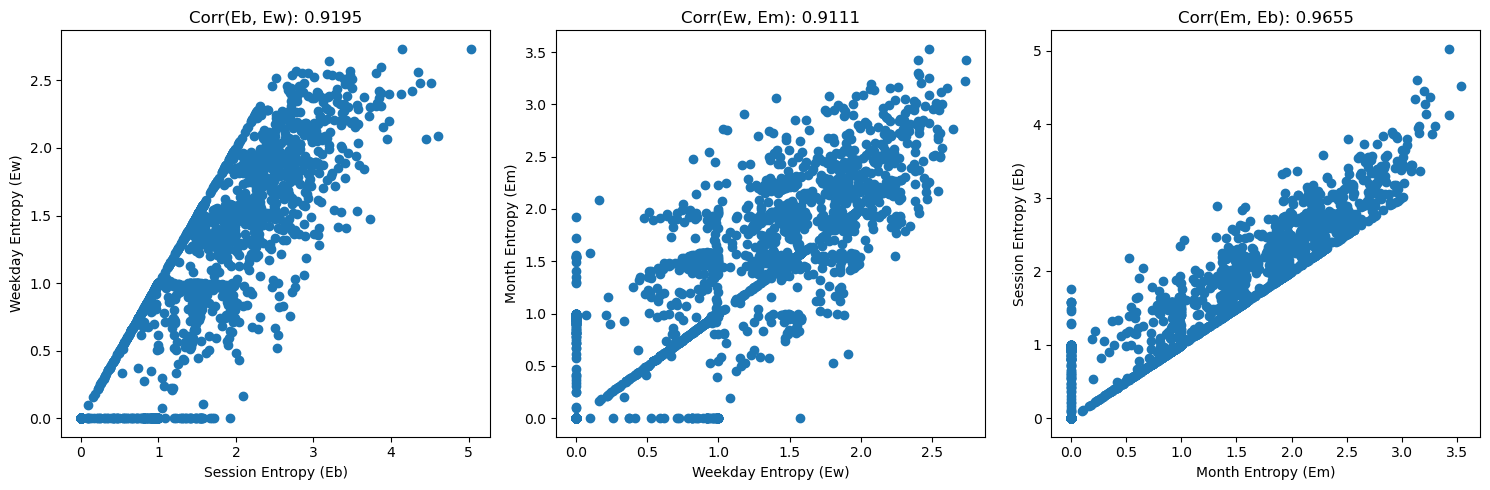

In [1100]:
# Plot the scatterplots for correlations among Eb, Ew, and Em
f, axs = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

# Scatterplot for SessionEntropy (Eb) vs WeekdayEntropy (Ew)
axs[0].scatter(customer_data['SessionEntropy'], customer_data['WeekdayEntropy'])
axs[0].set_title('Corr(Eb, Ew): {:.4f}'.format(
    customer_data['SessionEntropy'].corr(customer_data['WeekdayEntropy'])))
axs[0].set_xlabel('Session Entropy (Eb)')
axs[0].set_ylabel('Weekday Entropy (Ew)')

# Scatterplot for WeekdayEntropy (Ew) vs MonthEntropy (Em)
axs[1].scatter(customer_data['WeekdayEntropy'], customer_data['MonthEntropy'])
axs[1].set_title('Corr(Ew, Em): {:.4f}'.format(
    customer_data['WeekdayEntropy'].corr(customer_data['MonthEntropy'])))
axs[1].set_xlabel('Weekday Entropy (Ew)')
axs[1].set_ylabel('Month Entropy (Em)')

# Scatterplot for MonthEntropy (Em) vs SessionEntropy (Eb)
axs[2].scatter(customer_data['MonthEntropy'], customer_data['SessionEntropy'])
axs[2].set_title('Corr(Em, Eb): {:.4f}'.format(
    customer_data['MonthEntropy'].corr(customer_data['SessionEntropy'])))
axs[2].set_xlabel('Month Entropy (Em)')
axs[2].set_ylabel('Session Entropy (Eb)')

plt.tight_layout()
plt.show()

#### Observations:
1. A high positive correlation is observed between Session Entropy (Eb) and Weekday Entropy (Ew) with a value of 0.92, indicating that customers' session variability is closely related to the days they make purchases.
2. Weekday Entropy (Ew) and Month Entropy (Em) also show a strong correlation of 0.91, suggesting that purchasing behaviors over weekdays are consistent with their monthly purchase patterns.
3. Session Entropy (Eb) and Month Entropy (Em) has the strongest correlation at 0.97, reflecting that customers' session behavior significantly aligns with their monthly shopping trends.

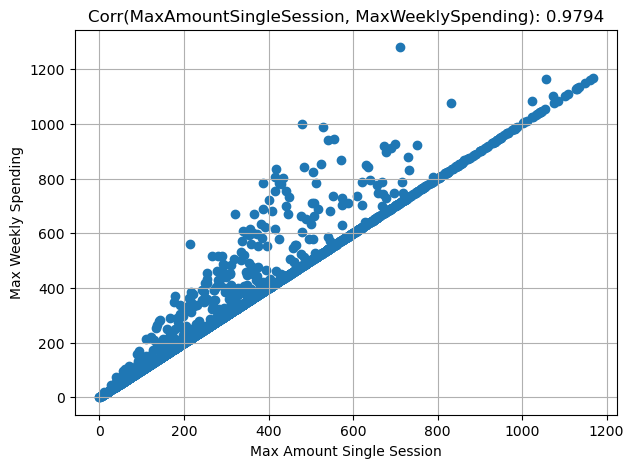

In [1107]:
# Scatterplot: Max Amount Single Session vs Max Weekly Spending
plt.figure(figsize=(7, 5))
plt.scatter(customer_data['MaxAmountSingleSession'], customer_data['MaxWeeklySpending'])
plt.title('Corr(MaxAmountSingleSession, MaxWeeklySpending): {:.4f}'.format(
    customer_data['MaxAmountSingleSession'].corr(customer_data['MaxWeeklySpending'])))
plt.xlabel('Max Amount Single Session')
plt.ylabel('Max Weekly Spending')
plt.grid(True)
plt.show()

- There is a strong positive correlation between the maximum amount spent in a single session and the maximum weekly spending. This indicates that customers who spend more in one session tend to have higher weekly expenditures overall.

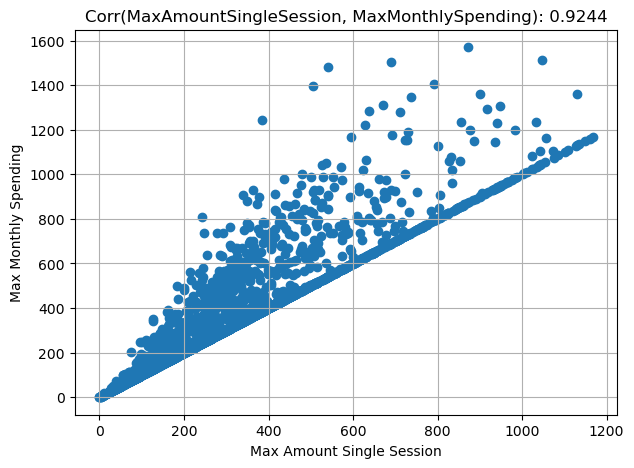

In [1108]:
# Scatterplot: Max Amount Single Session vs Max Monthly Spending
plt.figure(figsize=(7, 5))
plt.scatter(customer_data['MaxAmountSingleSession'], customer_data['MaxMonthlySpending'])
plt.title('Corr(MaxAmountSingleSession, MaxMonthlySpending): {:.4f}'.format(
    customer_data['MaxAmountSingleSession'].corr(customer_data['MaxMonthlySpending'])))
plt.xlabel('Max Amount Single Session')
plt.ylabel('Max Monthly Spending')
plt.grid(True)
plt.show()

- The strong correlation between the maximum amount spent in a single session and the maximum monthly spending suggests that customers with high single-session expenditures also have higher total monthly expenditures.

# Saving Numerical Attributes Dataset

In [1111]:
# Preparing numerical dataset for export
numerical_data = customer_data.drop(columns=[
    'TotalItemsRefunded', 'WeekdayEntropy', 'MonthEntropy', 'TotalAmountRefunded', 
    'MaxWeeklySpending', 'AvgWeeklySpending', 'MaxMonthlySpending', 'AvgMonthlySpending'
])

# Saving numerical dataset
numerical_data.to_csv('numerical_customer_data.csv', index=True)

print("Numerical attributes dataset stored as 'numerical_customer_data.csv'.")

Numerical attributes dataset stored as 'numerical_customer_data.csv'.


# Categorical Attributes Dataset

In [1112]:
# Saving categorical dataset
customer_data_categorical.to_csv('categorical_customer_data.csv', index=True)

# Output
print("Categorical attributes dataset stored as 'categorical_customer_data.csv'.")

Categorical attributes dataset stored as 'categorical_customer_data.csv'.
